<a href="https://colab.research.google.com/github/sajivjose174/Project/blob/main/Delhivery_Feature_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Business Case: Delhivery - Feature Engineering

##**About Delhivery**: Delhivery is the largest and fastest-growing fully integrated player in India by revenue in Fiscal 2021. They aim to build the  operating system for commerce, through a combination of world-class infrastructure, logistics operations of the highest quality, and cutting-edge engineering and technology capabilities




## Problem Statement: The company wants to understand and process the data coming out of data engineering pipelines.

In [ ]:
#Importing Required Libraries

import numpy as np
import pandas as pd
import math
from scipy.stats import binom
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import scipy.stats as spy
from scipy.stats import ttest_rel
from scipy.stats import shapiro
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

In [ ]:
#Loading the Dataset

!curl -o delhivery_data.csv "https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/551/original/delhivery_data.csv?1642751181"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 53.0M  100 53.0M    0     0   125M      0 --:--:-- --:--:-- --:--:--  125M


In [ ]:
df_Delhivery =pd.read_csv('delhivery_data.csv')
df_Delhivery.head()

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:01:19.505586,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:39:57,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:33:55,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000


In [ ]:
#Basic Information about the Dataset:
df_Delhivery.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   data                            144867 non-null  object 
 1   trip_creation_time              144867 non-null  object 
 2   route_schedule_uuid             144867 non-null  object 
 3   route_type                      144867 non-null  object 
 4   trip_uuid                       144867 non-null  object 
 5   source_center                   144867 non-null  object 
 6   source_name                     144574 non-null  object 
 7   destination_center              144867 non-null  object 
 8   destination_name                144606 non-null  object 
 9   od_start_time                   144867 non-null  object 
 10  od_end_time                     144867 non-null  object 
 11  start_scan_to_end_scan          144867 non-null  float64
 12  is_cutoff       

In [ ]:
#statistical summary:

df_Delhivery.describe()

,start_scan_to_end_scan,cutoff_factor,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
count,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.00000,144867.000000
mean,961.262986,232.926567,234.073372,416.927527,213.868272,284.771297,2.120107,36.196111,18.507548,22.82902,2.218368
std,1037.012769,344.755577,344.990009,598.103621,308.011085,421.119294,1.715421,53.571158,14.775960,17.86066,4.847530
min,20.000000,9.000000,9.000045,9.000000,6.000000,9.008200,0.144000,-244.000000,0.000000,0.00000,-23.444444
25%,161.000000,22.000000,23.355874,51.000000,27.000000,29.914700,1.604264,20.000000,11.000000,12.07010,1.347826
50%,449.000000,66.000000,66.126571,132.000000,64.000000,78.525800,1.857143,29.000000,17.000000,23.51300,1.684211
75%,1634.000000,286.000000,286.708875,513.000000,257.000000,343.193250,2.213483,40.000000,22.000000,27.81325,2.250000
max,7898.000000,1927.000000,1927.447705,4532.000000,1686.000000,2326.199100,77.387097,3051.000000,1611.000000,2191.40370,574.250000


In [ ]:
#unique entries present in each column:

for i in df_Delhivery.columns:
 print(f"Unique entries for column {i:<30} = {df_Delhivery[i].nunique()}")


Unique entries for column data                           = 2
Unique entries for column trip_creation_time             = 14817
Unique entries for column route_schedule_uuid            = 1504
Unique entries for column route_type                     = 2
Unique entries for column trip_uuid                      = 14817
Unique entries for column source_center                  = 1508
Unique entries for column source_name                    = 1498
Unique entries for column destination_center             = 1481
Unique entries for column destination_name               = 1468
Unique entries for column od_start_time                  = 26369
Unique entries for column od_end_time                    = 26369
Unique entries for column start_scan_to_end_scan         = 1915
Unique entries for column is_cutoff                      = 2
Unique entries for column cutoff_factor                  = 501
Unique entries for column cutoff_timestamp               = 93180
Unique entries for column actual_distance_to_

In [ ]:
#convert trip_creation_time to time series:

df_Delhivery['trip_creation_time']=pd.to_datetime(df_Delhivery['trip_creation_time'])
df_Delhivery['od_start_time']=pd.to_datetime(df_Delhivery['od_start_time'])
df_Delhivery['od_end_time']=pd.to_datetime(df_Delhivery['od_end_time'])

In [ ]:
#null value checke:
df_Delhivery.isnull().sum()

,0
data,0
trip_creation_time,0
route_schedule_uuid,0
route_type,0
trip_uuid,0
source_center,0
source_name,293
destination_center,0
destination_name,261
od_start_time,0


In [ ]:
#null value treatment (drop nulls as the number of nulls are less and imputation without clarity would cause bias):

df_Delhivery=df_Delhivery.dropna(subset=['source_name','destination_name'])

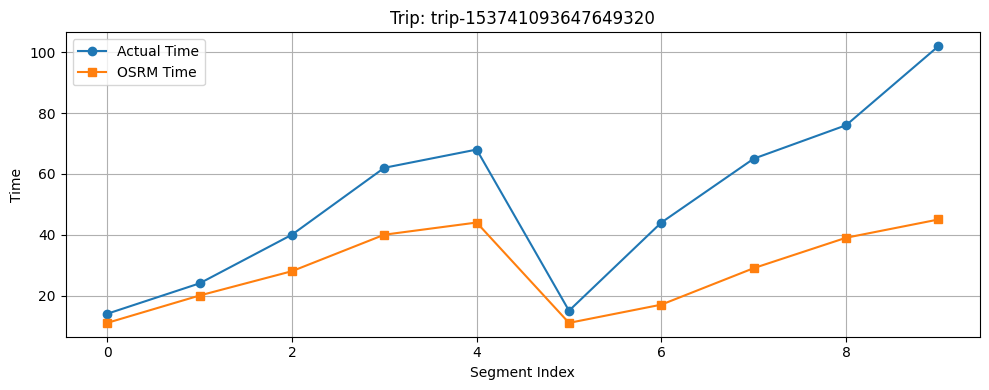

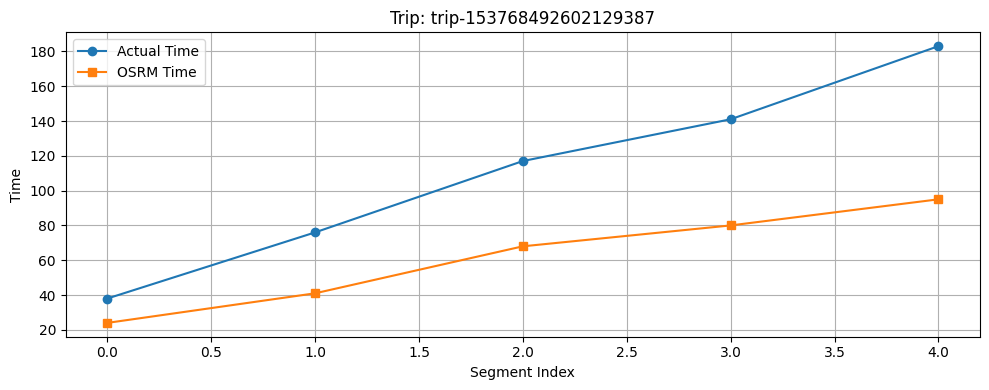

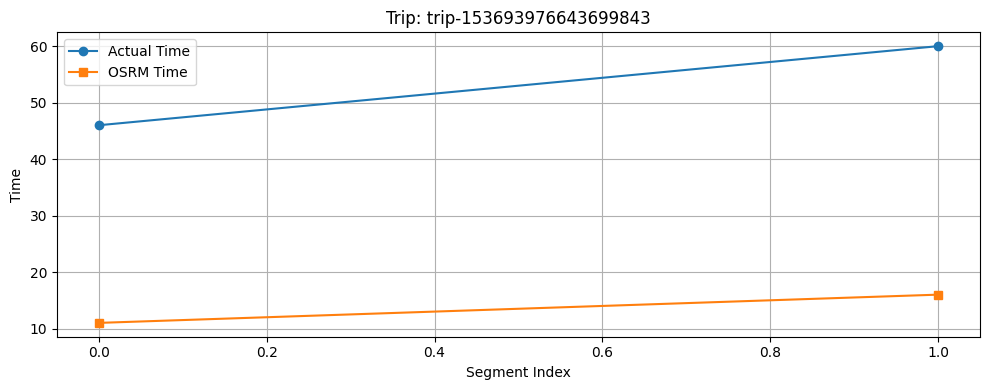

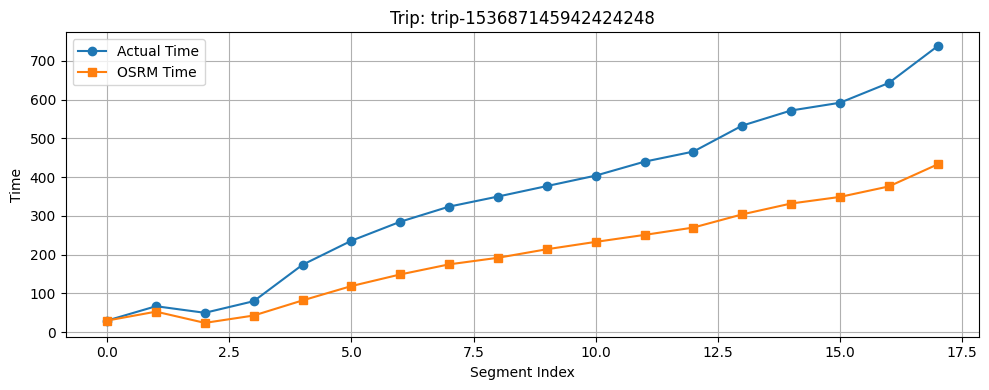

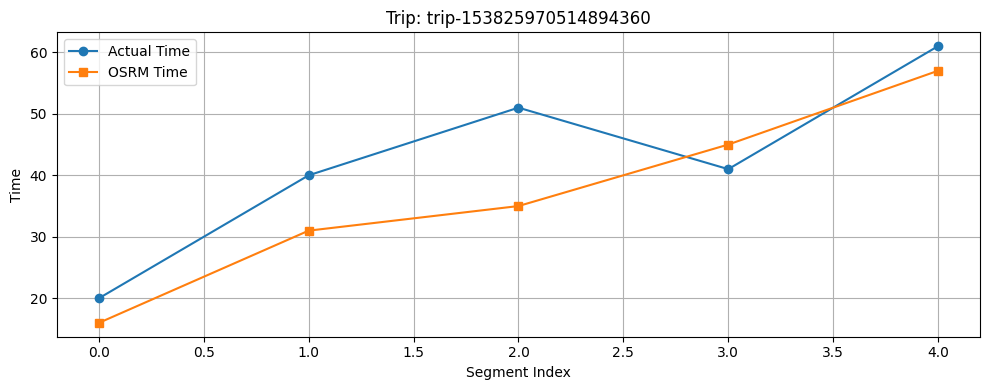

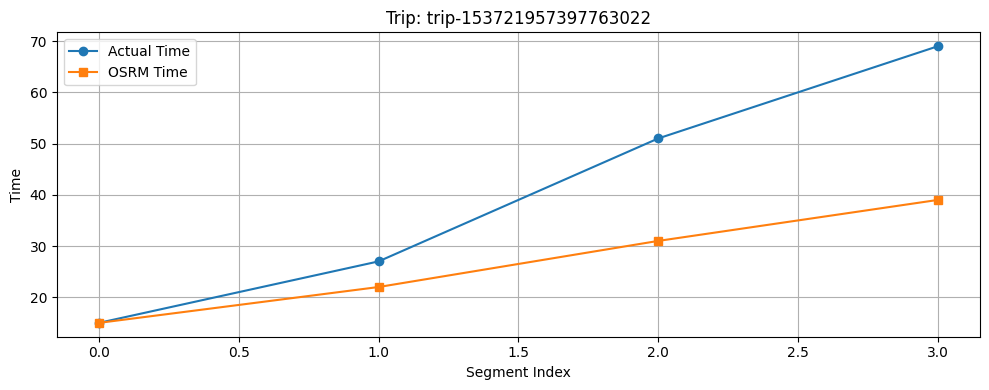

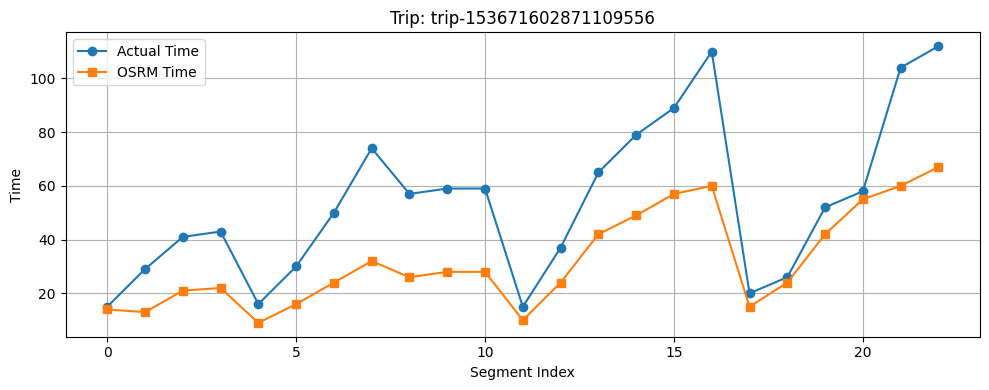

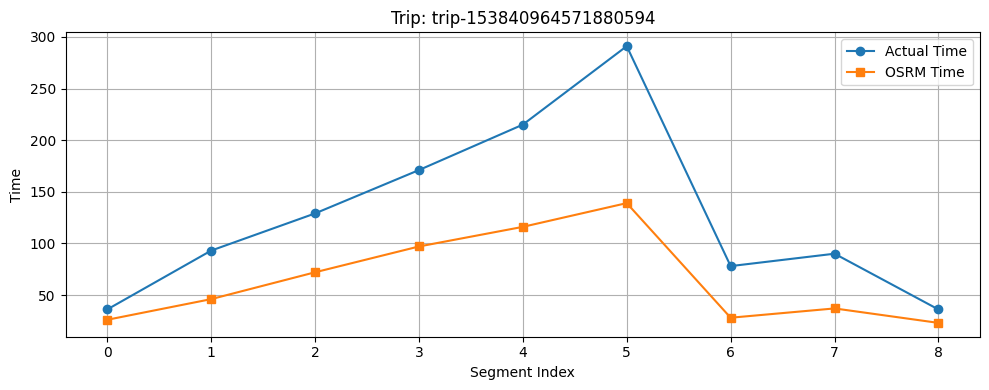

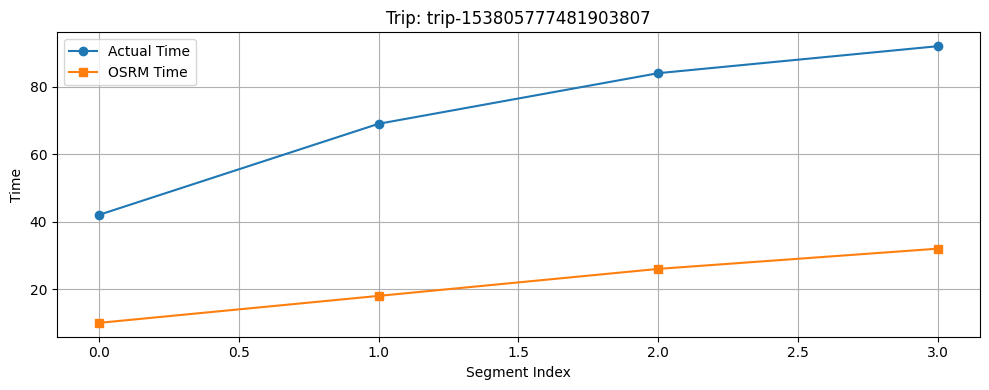

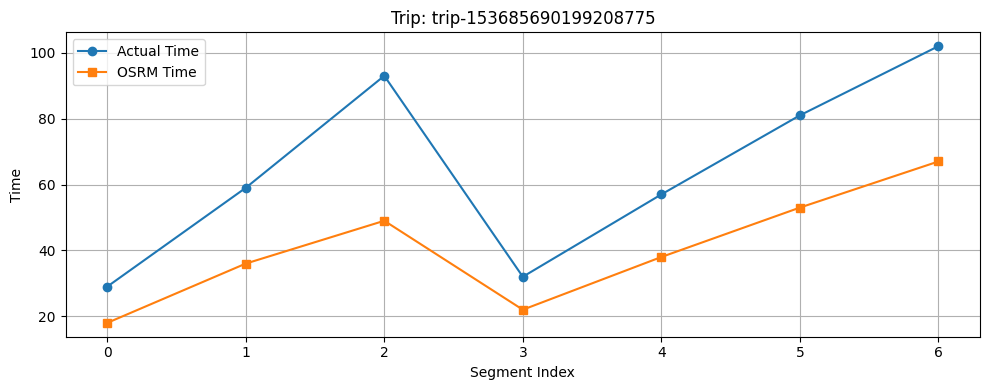

In [ ]:
#check to see if the columns are cumulative or not:
sample_trips = df_Delhivery['trip_uuid'].unique()[:10]
for trip in sample_trips:
    trip_df = df_Delhivery[df_Delhivery['trip_uuid'] == trip].reset_index(drop=True)

    plt.figure(figsize=(10, 4))
    plt.plot(trip_df.index, trip_df['actual_time'], marker='o', label='Actual Time')
    plt.plot(trip_df.index, trip_df['osrm_time'], marker='s', label='OSRM Time')

    plt.title(f"Trip: {trip}")
    plt.xlabel("Segment Index")
    plt.ylabel("Time")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
#shape of dataset:
df_Delhivery.shape

(144316, 24)

In [ ]:
#unique elements in each column:

for i in df_Delhivery.columns:
  print(i,':',df_Delhivery[i].unique())

data : ['training' 'test']
trip_creation_time : <DatetimeArray>
['2018-09-20 02:35:36.476840', '2018-09-23 06:42:06.021680',
 '2018-09-14 15:42:46.437249', '2018-09-13 20:44:19.424489',
 '2018-09-29 22:21:45.149226', '2018-09-17 21:26:00.454695',
 '2018-09-12 01:33:48.711350', '2018-10-01 16:00:45.719099',
 '2018-09-27 14:16:14.819357', '2018-09-13 16:41:41.992300',
 ...
 '2018-09-13 20:47:45.942988', '2018-10-01 19:56:20.111591',
 '2018-09-23 01:31:09.129173', '2018-10-01 18:17:37.047270',
 '2018-09-26 14:05:52.096792', '2018-09-26 19:50:29.657378',
 '2018-09-14 18:45:34.164734', '2018-09-22 11:30:41.399439',
 '2018-09-17 11:35:28.838714', '2018-09-20 16:24:28.436231']
Length: 14787, dtype: datetime64[ns]
route_schedule_uuid : ['thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3297ef'
 'thanos::sroute:ff52ef7a-4d0d-4063-9bfe-cc211728881b'
 'thanos::sroute:a16bfa03-3462-4bce-9c82-5784c7d315e6' ...
 'thanos::sroute:72cf9feb-f4e3-4a55-b92a-0b686ee8fabc'
 'thanos::sroute:5e08be79-8a4c-4a91-a5

In [ ]:
df1=df_Delhivery
df1

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:01:19.505586,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:39:57,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:33:55,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144862,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,Carting,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-20 16:24:28.436231,...,2018-09-20 21:57:20,45.258278,94.0,60.0,67.9280,1.566667,12.0,12.0,8.1858,1.000000
144863,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,Carting,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-20 16:24:28.436231,...,2018-09-20 21:31:18,54.092531,120.0,76.0,85.6829,1.578947,26.0,21.0,17.3725,1.238095
144864,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,Carting,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-20 16:24:28.436231,...,2018-09-20 21:11:18,66.163591,140.0,88.0,97.0933,1.590909,20.0,34.0,20.7053,0.588235
144865,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,Carting,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-20 16:24:28.436231,...,2018-09-20 20:53:19,73.680667,158.0,98.0,111.2709,1.612245,17.0,27.0,18.8885,0.629630


#Feature Extraction:

In [ ]:
#Destination Name extraction
df1[['City_destination','state_destination']]=df1['destination_name'].str.split(' ',n=1,expand=True)
df1['state_destination']=df1['state_destination'].str.strip('()')
df1[['city_destination','place_destination']]=df1['City_destination'].str.split('_',n=1,expand=True)
#df1.drop(columns='palce_destination',inplace=True)
df1.drop(columns='City_destination',inplace=True)
#df1.drop(columns='destination_name',inplace=True)
df1.head()

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor,state_destination,city_destination,place_destination
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727,Gujarat,Khambhat,MotvdDPP_D
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111,Gujarat,Khambhat,MotvdDPP_D
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714,Gujarat,Khambhat,MotvdDPP_D
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000,Gujarat,Khambhat,MotvdDPP_D
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000,Gujarat,Khambhat,MotvdDPP_D


In [ ]:
#Source Name extraction
df1[['City_source','state_source']]=df1['source_name'].str.split(' ',n=1,expand=True)
df1['state_source']=df1['state_source'].str.strip('()')
df1[['city_source','place_source']]=df1['City_source'].str.split('_',n=1,expand=True)
#df1.drop(columns='palce_source',inplace=True)
df1.drop(columns='City_source',inplace=True)
#df1.drop(columns='source_name',inplace=True)
df1.head()

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor,state_destination,city_destination,place_destination,state_source,city_source,place_source
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,14.0,11.0,11.9653,1.272727,Gujarat,Khambhat,MotvdDPP_D,Gujarat,Anand,VUNagar_DC
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,10.0,9.0,9.7590,1.111111,Gujarat,Khambhat,MotvdDPP_D,Gujarat,Anand,VUNagar_DC
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,16.0,7.0,10.8152,2.285714,Gujarat,Khambhat,MotvdDPP_D,Gujarat,Anand,VUNagar_DC
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,21.0,12.0,13.0224,1.750000,Gujarat,Khambhat,MotvdDPP_D,Gujarat,Anand,VUNagar_DC
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,6.0,5.0,3.9153,1.200000,Gujarat,Khambhat,MotvdDPP_D,Gujarat,Anand,VUNagar_DC


In [ ]:
#Extract features like month, year and day of name:
df1['day_name'] = df1['trip_creation_time'].dt.day_name()
df1['month']=df1['trip_creation_time'].dt.month
df1['year']=df1['trip_creation_time'].dt.year
df1['hour'] = df1['trip_creation_time'].dt.hour
df1['days']=df1['trip_creation_time'].dt.day
#df1['hour']=df1['trip_creation_time'].dt.hour
#df1.drop(columns='trip_creation_time',inplace=True)
df1.head()

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,city_destination,place_destination,state_source,city_source,place_source,day_name,month,year,hour,days
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,Khambhat,MotvdDPP_D,Gujarat,Anand,VUNagar_DC,Thursday,9,2018,2,20
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,Khambhat,MotvdDPP_D,Gujarat,Anand,VUNagar_DC,Thursday,9,2018,2,20
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,Khambhat,MotvdDPP_D,Gujarat,Anand,VUNagar_DC,Thursday,9,2018,2,20
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,Khambhat,MotvdDPP_D,Gujarat,Anand,VUNagar_DC,Thursday,9,2018,2,20
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,Khambhat,MotvdDPP_D,Gujarat,Anand,VUNagar_DC,Thursday,9,2018,2,20


#Merging of rows and aggregation of fields, followed by build some features to prepare the data for actual analysis. Extract features from the below fields:

In [ ]:
grouping_1 = ['trip_uuid', 'source_center', 'destination_center']

agg1 = df1.groupby(by=grouping_1, as_index=False).agg({
    'data': 'first',
    'route_type': 'first',
    'trip_creation_time': 'first',
    'source_name': 'first',
    'destination_name': 'last',
    'state_source': 'first',
    'city_source': 'first',
    'place_source': 'first',
    'state_destination': 'last',
    'city_destination': 'last',
    'place_destination': 'last',
    'day_name': 'first',
    'month': 'first',
    'year': 'first',
    'hour': 'first',
    'days':'first',
    #'hour':'first',
    'od_start_time': 'first',
    'od_end_time': 'first',
    'start_scan_to_end_scan': 'first',
    'actual_distance_to_destination': 'last',
    'actual_time': 'last',
    'osrm_time': 'last',
    'osrm_distance': 'last',
    'segment_actual_time': 'sum',
    'segment_osrm_time': 'sum',
    'segment_osrm_distance': 'sum'
})

In [ ]:
agg1.shape

(26222, 29)

In [ ]:


agg1['od_total_time'] = agg1['od_end_time'] - agg1['od_start_time']
agg1.drop(columns = ['od_end_time', 'od_start_time'], inplace = True)
agg1['od_total_time'] = agg1['od_total_time'].apply(lambda x : round(x.total_seconds() / 60.0, 2))
agg1['od_total_time'].head()


,od_total_time
0,1260.60
1,999.51
2,58.83
3,122.78
4,834.64


In [ ]:
agg2 = agg1.groupby(by='trip_uuid', as_index=False).agg({
    'source_center': 'first',
    'destination_center': 'last',
    'data': 'first',
    'route_type': 'first',
    'trip_creation_time': 'first',
    'source_name': 'first',
    'destination_name': 'last',
    'state_source': 'first',
    'city_source': 'first',
    'place_source': 'first',
    'state_destination': 'last',
    'city_destination': 'last',
    'place_destination': 'last',
    'day_name': 'first',
    'month': 'first',
    'year': 'first',
    #'hour': 'first',
    'days':'first',
    'hour':'first',
    'od_total_time': 'sum',
    'start_scan_to_end_scan': 'sum',
    'actual_distance_to_destination': 'sum',
    'actual_time': 'sum',
    'osrm_time': 'sum',
    'osrm_distance': 'sum',
    'segment_actual_time': 'sum',
    'segment_osrm_time': 'sum',
    'segment_osrm_distance': 'sum'
})


In [ ]:
agg2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14787 entries, 0 to 14786
Data columns (total 28 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   trip_uuid                       14787 non-null  object        
 1   source_center                   14787 non-null  object        
 2   destination_center              14787 non-null  object        
 3   data                            14787 non-null  object        
 4   route_type                      14787 non-null  object        
 5   trip_creation_time              14787 non-null  datetime64[ns]
 6   source_name                     14787 non-null  object        
 7   destination_name                14787 non-null  object        
 8   state_source                    14787 non-null  object        
 9   city_source                     14787 non-null  object        
 10  place_source                    14273 non-null  object        
 11  st

In [ ]:
agg2.describe()

,trip_creation_time,month,year,days,hour,od_total_time,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance
count,14787,14787.000000,14787.0,14787.000000,14787.000000,14787.000000,14787.000000,14787.000000,14787.000000,14787.000000,14787.000000,14787.000000,14787.000000,14787.000000
mean,2018-09-22 12:26:28.269885696,9.120105,2018.0,18.375127,12.456212,530.313468,529.429025,164.090196,356.306012,160.990938,203.887411,353.059174,180.511598,222.705466
min,2018-09-12 00:00:16.535741,9.000000,2018.0,1.000000,0.000000,23.460000,23.000000,9.002461,9.000000,6.000000,9.072900,9.000000,6.000000,9.072900
25%,2018-09-17 02:38:18.128431872,9.000000,2018.0,14.000000,4.000000,149.695000,149.000000,22.777099,67.000000,29.000000,30.756900,66.000000,30.000000,32.578850
50%,2018-09-22 03:39:19.609193984,9.000000,2018.0,19.000000,14.000000,279.710000,279.000000,48.287894,148.000000,60.000000,65.302800,147.000000,65.000000,69.784200
75%,2018-09-27 19:23:14.074359552,9.000000,2018.0,25.000000,20.000000,633.535000,632.000000,163.591258,367.000000,168.000000,206.644200,364.000000,184.000000,216.560600
max,2018-10-03 23:59:42.701692,10.000000,2018.0,30.000000,23.000000,7898.550000,7898.000000,2186.531787,6265.000000,2032.000000,2840.081000,6230.000000,2564.000000,3523.632400
std,NaN,0.325096,0.0,7.882198,7.987387,658.415416,658.254936,305.502982,561.517936,271.459495,370.565564,556.365911,314.679279,416.846279




#Visualisations and Plots:

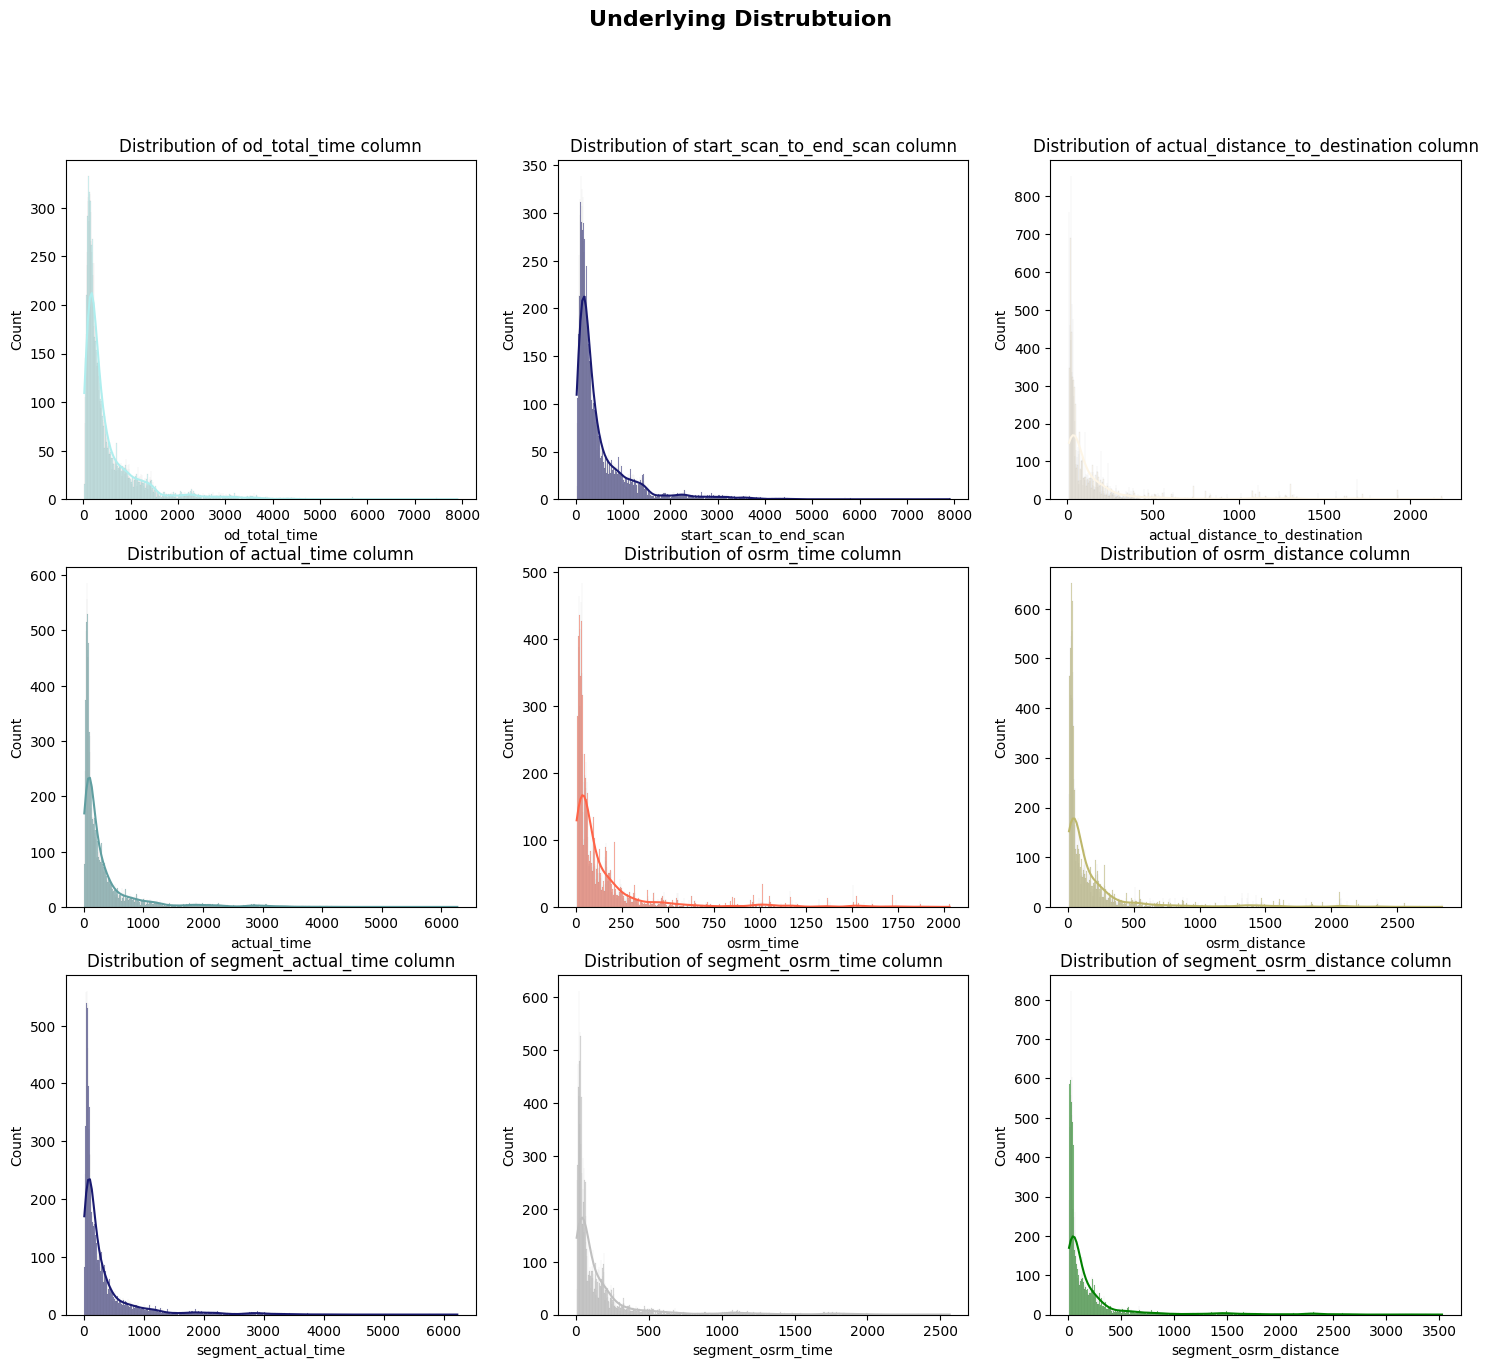

In [ ]:
#Underlying Distrubtuion:

numerical_columns = ['od_total_time', 'start_scan_to_end_scan', 'actual_distance_to_destination',
 'actual_time', 'osrm_time', 'osrm_distance', 'segment_actual_time',
 'segment_osrm_time', 'segment_osrm_distance']
agg2[numerical_columns].describe().T



plt.figure(figsize = (18, 15))
for i in range(len(numerical_columns)):
 plt.subplot(3, 3, i + 1)
 clr = np.random.choice(list(mpl.colors.cnames))
 sns.histplot(agg2[numerical_columns[i]], bins = 1000, kde = True, color = clr)
 plt.title(f"Distribution of {numerical_columns[i]} column")
 plt.suptitle("Underlying Distrubtuion", fontsize=16, fontweight='bold')
 plt.plot()

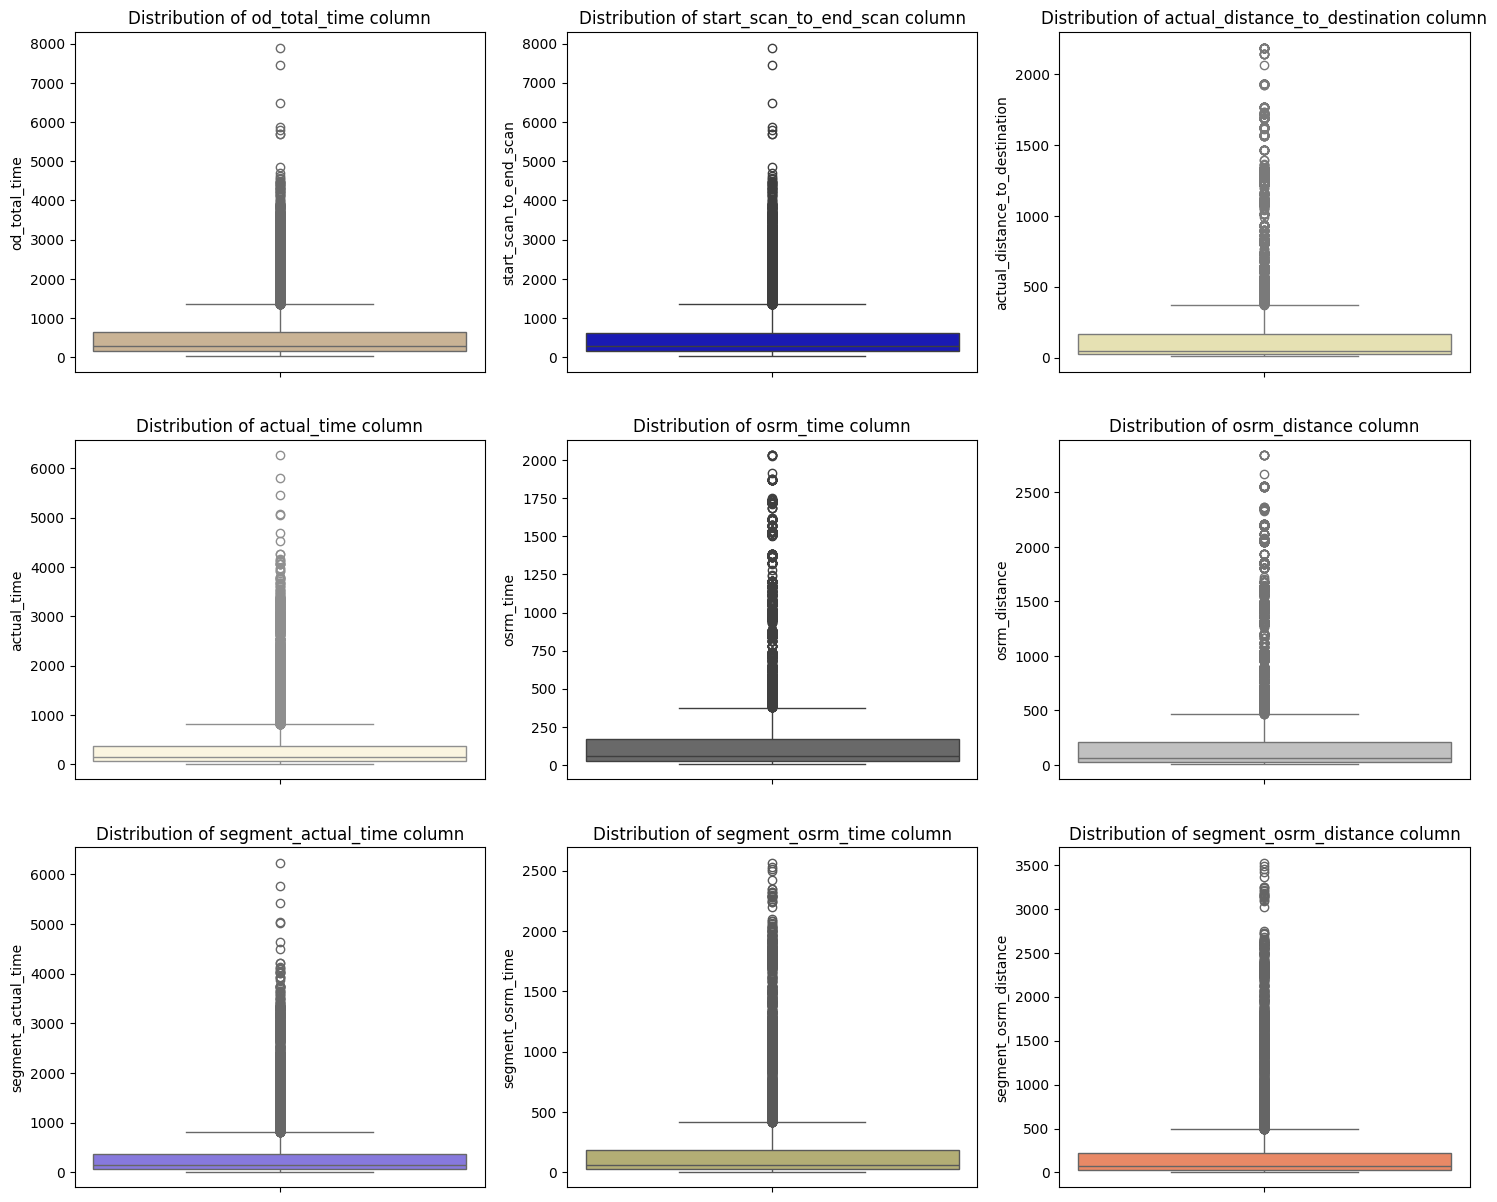

In [ ]:
#outliers checks (visuals):
plt.figure(figsize = (18, 15))
for i in range(len(numerical_columns)):
 plt.subplot(3, 3, i + 1)
 clr = np.random.choice(list(mpl.colors.cnames))
 sns.boxplot(agg2[numerical_columns[i]], color = clr)
 plt.title(f"Distribution of {numerical_columns[i]} column")
plt.suptitle("Plot to show outliers", fontsize=16, fontweight='bold')
 plt.plot()

In [ ]:
#above plots there are outliers in all the numerical columns that need to be treated

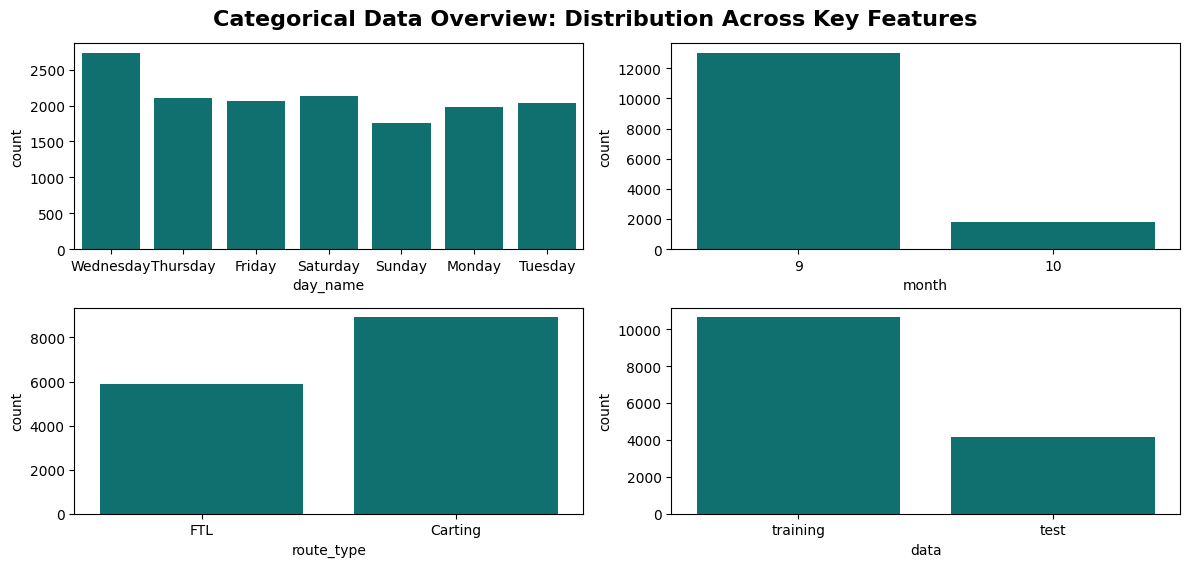

In [ ]:
#Categorical Data Overview: Distribution Across Key Features (covers all the needed barplots,histogram from the dataset):
plt.figure(figsize=(12,8))
#1. weather barplots
plt.subplot(3,2,1)
sns.countplot(data=agg2,x='day_name',color='Teal')
#2. season barplots
plt.subplot(3,2,2)
sns.countplot(data=agg2, x='month', color='Teal')
#3.casual histogram
plt.subplot(3,2,3)
sns.countplot(data=agg2, x='route_type', color='Teal')
#4.registered histogram
plt.subplot(3,2,4)
sns.countplot(data=agg2, x='data', color='Teal')
#plt.subplot(3,2,5)
#sns.countplot(data=agg2, x='route_type', color='Teal')
plt.suptitle("Categorical Data Overview: Distribution Across Key Features", fontsize=16, fontweight='bold')
plt.tight_layout()

/tmp/ipython-input-91-626811781.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_counts.values, y=state_counts.index, palette='viridis')


<Figure size 1000x1500 with 0 Axes>

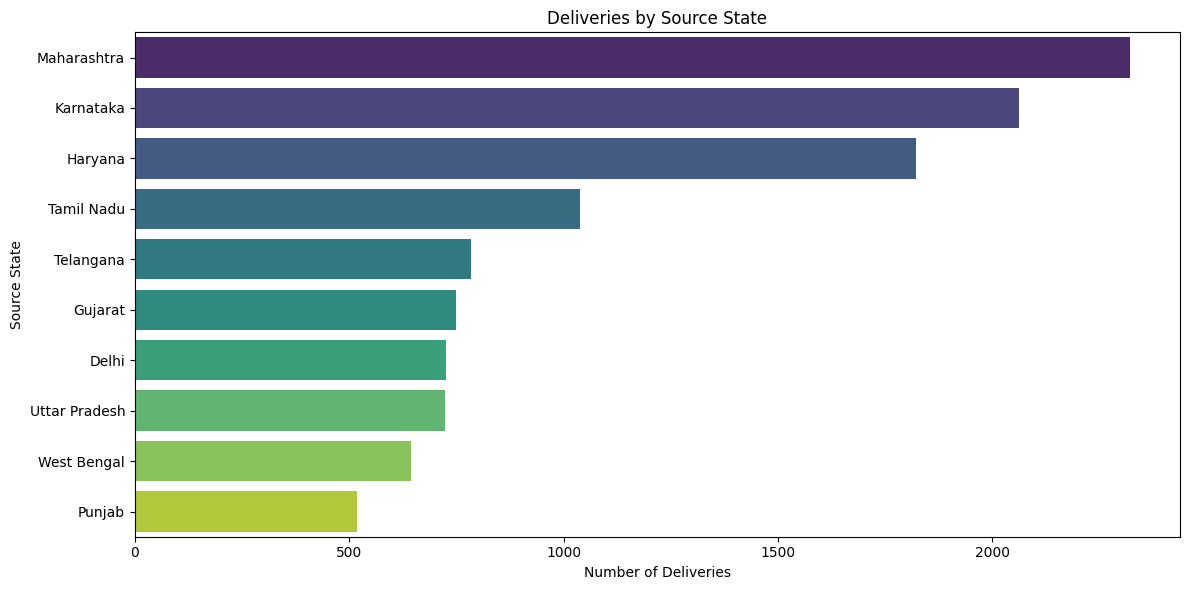

In [ ]:
#Deliveries by Source State
plt.figure(figsize = (10, 15))
state_counts = agg2['state_source'].value_counts().head(10)
plt.figure(figsize=(12, max(6, len(state_counts) * 0.3)))
sns.barplot(x=state_counts.values, y=state_counts.index, palette='viridis')
plt.title("Deliveries by Source State")
plt.xlabel("Number of Deliveries")
plt.ylabel("Source State")
plt.tight_layout()
plt.show()

/tmp/ipython-input-92-2766277158.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_counts.values, y=state_counts.index, palette='viridis')


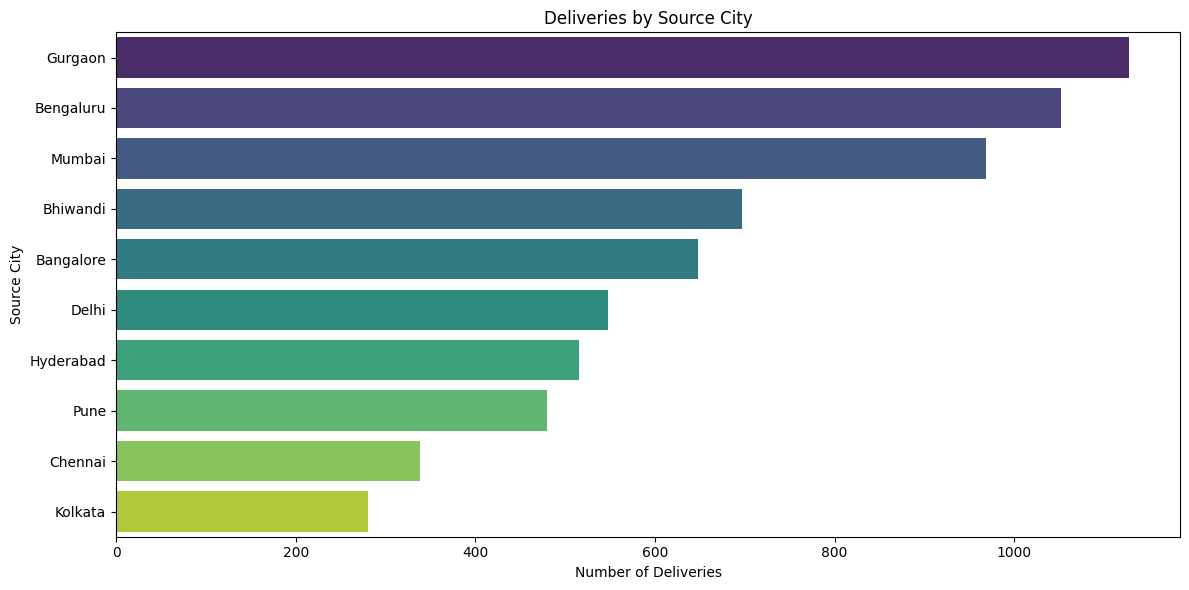

In [ ]:
#Deliveries by Source City
state_counts = agg2['city_source'].value_counts().head(10)
plt.figure(figsize=(12, max(6, len(state_counts) * 0.3)))
sns.barplot(x=state_counts.values, y=state_counts.index, palette='viridis')
plt.title("Deliveries by Source City")
plt.xlabel("Number of Deliveries")
plt.ylabel("Source City")
plt.tight_layout()
plt.show()

/tmp/ipython-input-93-3684730903.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_counts.values, y=state_counts.index, palette='viridis')


<Figure size 1000x1500 with 0 Axes>

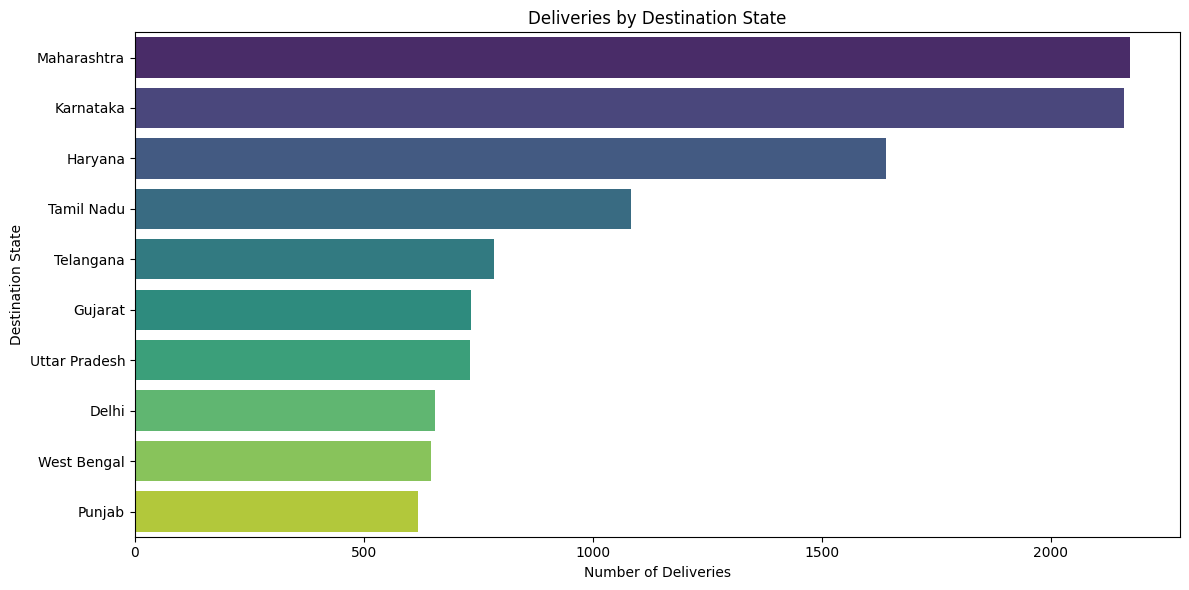

In [ ]:
#Deliveries by Destination State
plt.figure(figsize = (10, 15))
state_counts = agg2['state_destination'].value_counts().head(10)
plt.figure(figsize=(12, max(6, len(state_counts) * 0.3)))
sns.barplot(x=state_counts.values, y=state_counts.index, palette='viridis')
plt.title("Deliveries by Destination State")
plt.xlabel("Number of Deliveries")
plt.ylabel("Destination State")
plt.tight_layout()
plt.show()

/tmp/ipython-input-94-2650577973.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_counts.values, y=state_counts.index, palette='viridis')


<Figure size 1000x1500 with 0 Axes>

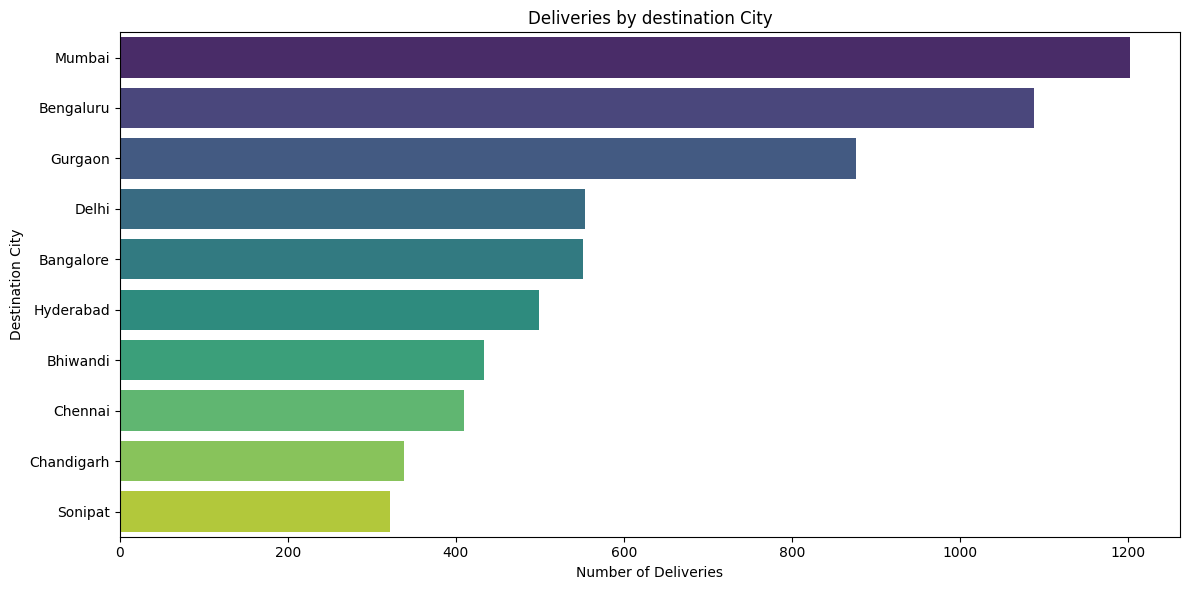

In [ ]:
#Deliveries by destination City

plt.figure(figsize = (10, 15))
state_counts = agg2['city_destination'].value_counts().head(10)
plt.figure(figsize=(12, max(6, len(state_counts) * 0.3)))
sns.barplot(x=state_counts.values, y=state_counts.index, palette='viridis')
plt.title("Deliveries by destination City")
plt.xlabel("Number of Deliveries")
plt.ylabel("Destination City")
plt.tight_layout()
plt.show()

[]

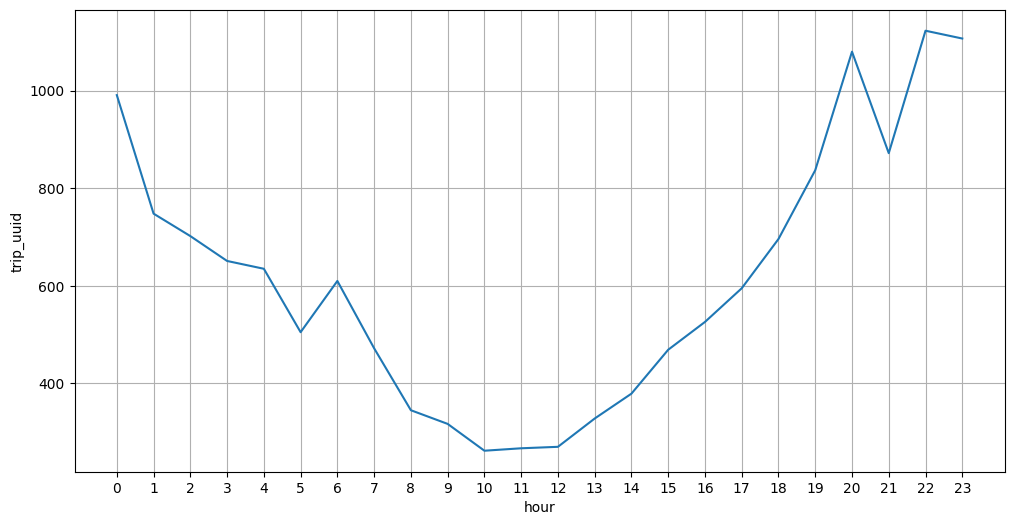

In [ ]:
#trips on the hourly basis:

df_hour = agg2.groupby(by = 'hour')['trip_uuid'].count().to_frame().reset_index()
plt.figure(figsize = (12, 6))
sns.lineplot(data = df_hour,
 x = df_hour['hour'],
 y = df_hour['trip_uuid'],
 markers = '*')
plt.xticks(np.arange(0,24))
plt.grid('both')
plt.plot()


It can be inferred from the above plot that the number of trips start increasing after the noon, becomes maximum at 10 P.M and then start
decreasing.


In [ ]:
df_day = agg2.groupby(by = 'days')['trip_uuid'].count().to_frame().reset_index()
df_day.head()

,days,trip_uuid
0,1,600
1,2,549
2,3,627
3,12,747
4,13,750


[]

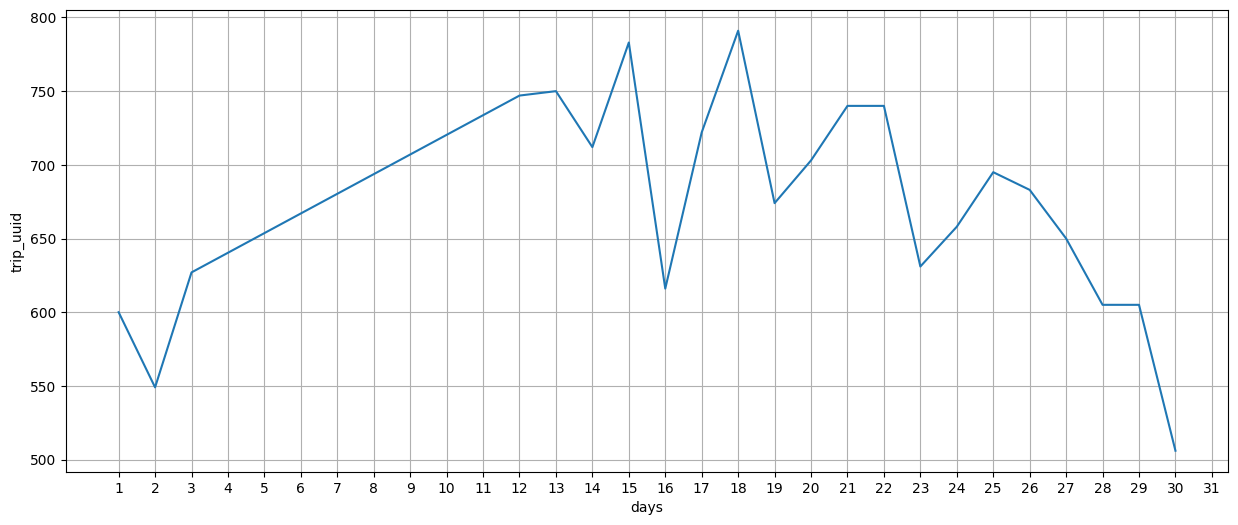

In [ ]:
#trips for different days of the month.

plt.figure(figsize = (15, 6))
sns.lineplot(data = df_hour,
 x = df_day['days'],
 y = df_day['trip_uuid'],
 markers = '*')
plt.xticks(np.arange(1,32))
plt.grid('both')
plt.plot()

[]

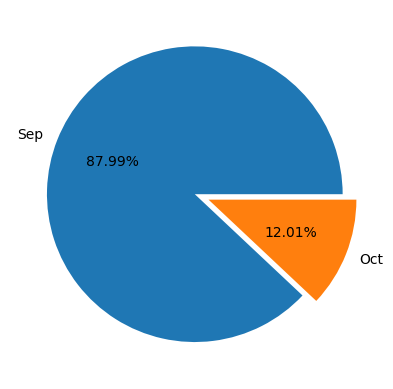

In [ ]:
#distribution of months for the orders:

df_month = agg2.groupby(by = 'month')['trip_uuid'].count().to_frame().reset_index()
labels = df_month['month'].astype(str).tolist()
plt.pie(x = df_month['trip_uuid'],
  labels=['Sep', 'Oct'],
 explode = [0, 0.1],
 autopct = '%.2f%%')
plt.plot()

[]

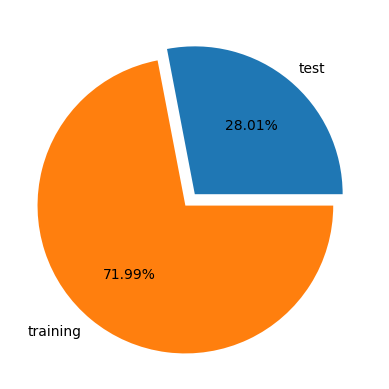

In [ ]:
#distribution of trip data for the orders

df_data = agg2.groupby(by = 'data')['trip_uuid'].count().to_frame().reset_index()
df_data.head()
plt.pie(x = df_data['trip_uuid'],
 labels = df_data['data'],
 explode = [0, 0.1],
 autopct = '%.2f%%')
plt.plot()


[]

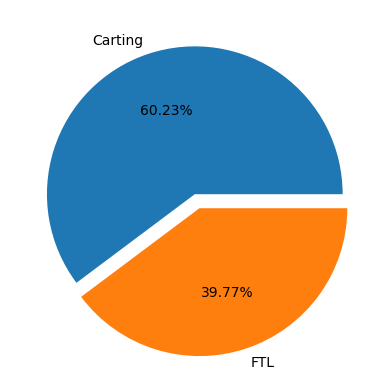

In [ ]:
# distribution of route types for the orders:

df_route = agg2.groupby(by = 'route_type')['trip_uuid'].count().to_frame().reset_index()
df_route.head()
plt.pie(x = df_route['trip_uuid'],
 labels = ['Carting', 'FTL'],
 explode = [0, 0.1],
 autopct = '%.2f%%')
plt.plot()



[]

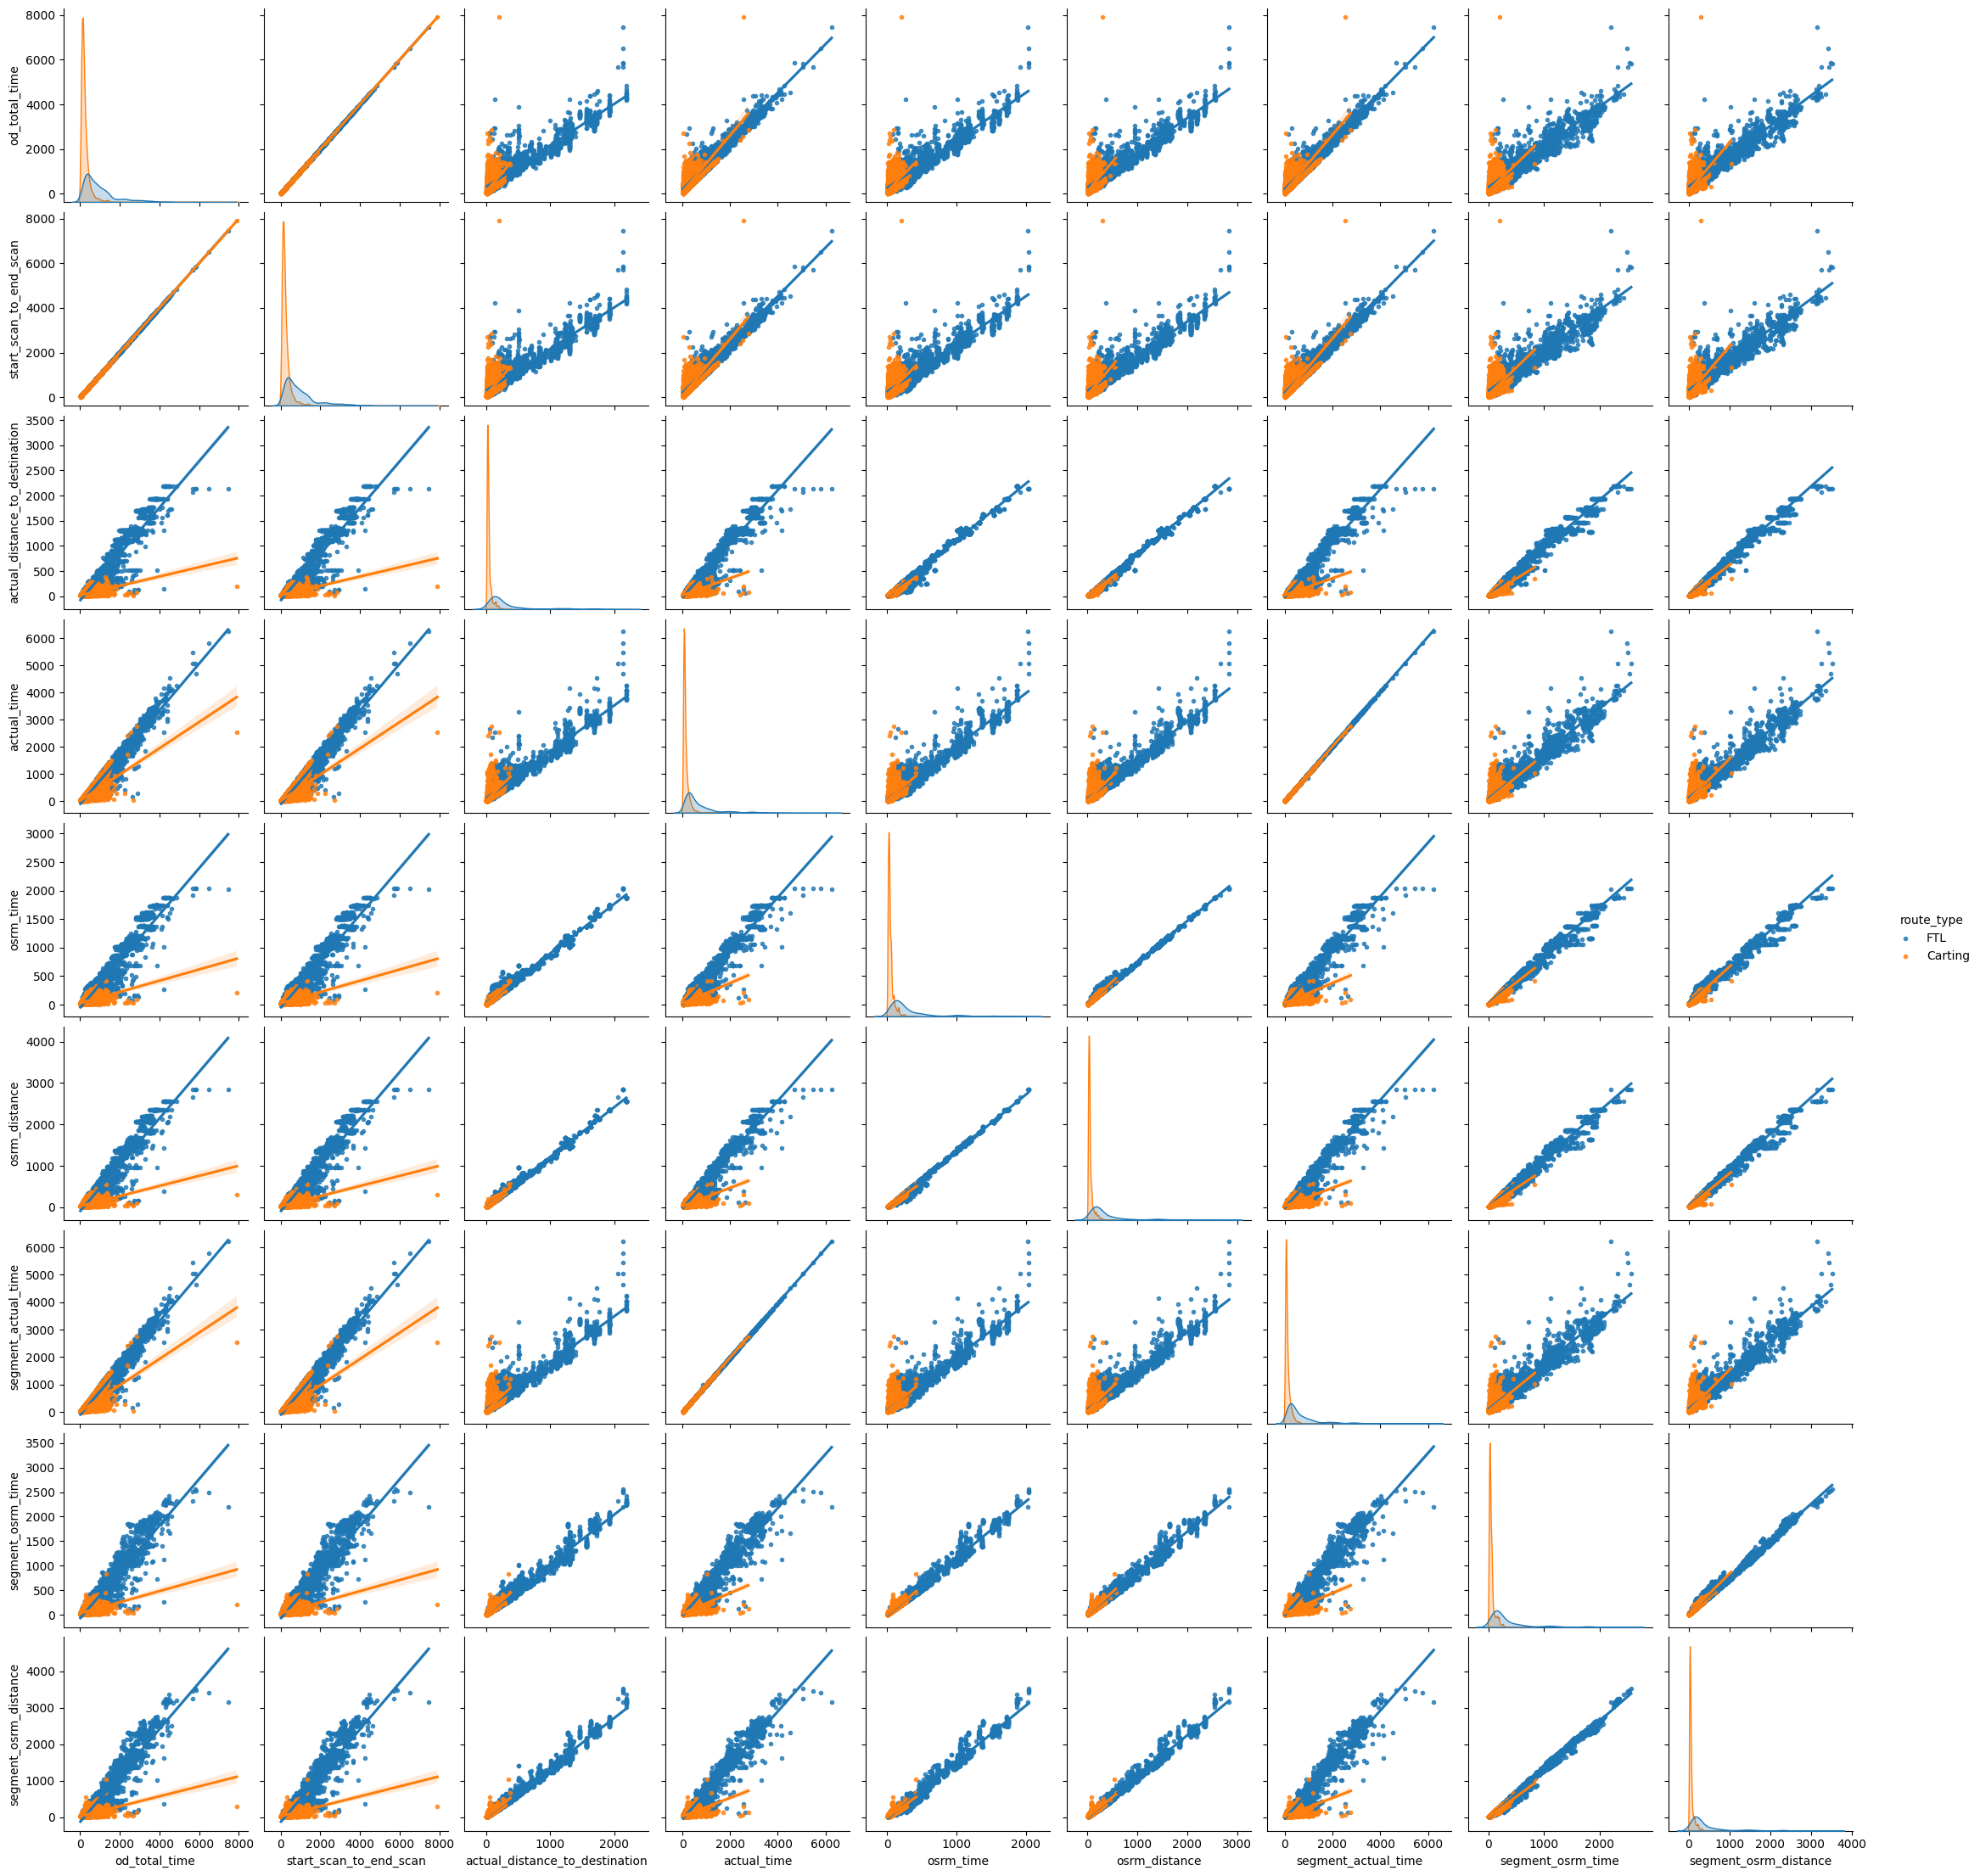

In [ ]:
#pairplot for numerical columns:

numerical_columns = ['od_total_time', 'start_scan_to_end_scan', 'actual_distance_to_destination',
 'actual_time', 'osrm_time', 'osrm_distance', 'segment_actual_time',
 'segment_osrm_time', 'segment_osrm_distance']
sns.pairplot(data = agg2,
 vars = numerical_columns,
 kind = 'reg',
 hue = 'route_type',
 markers = '.')
plt.plot()

[]

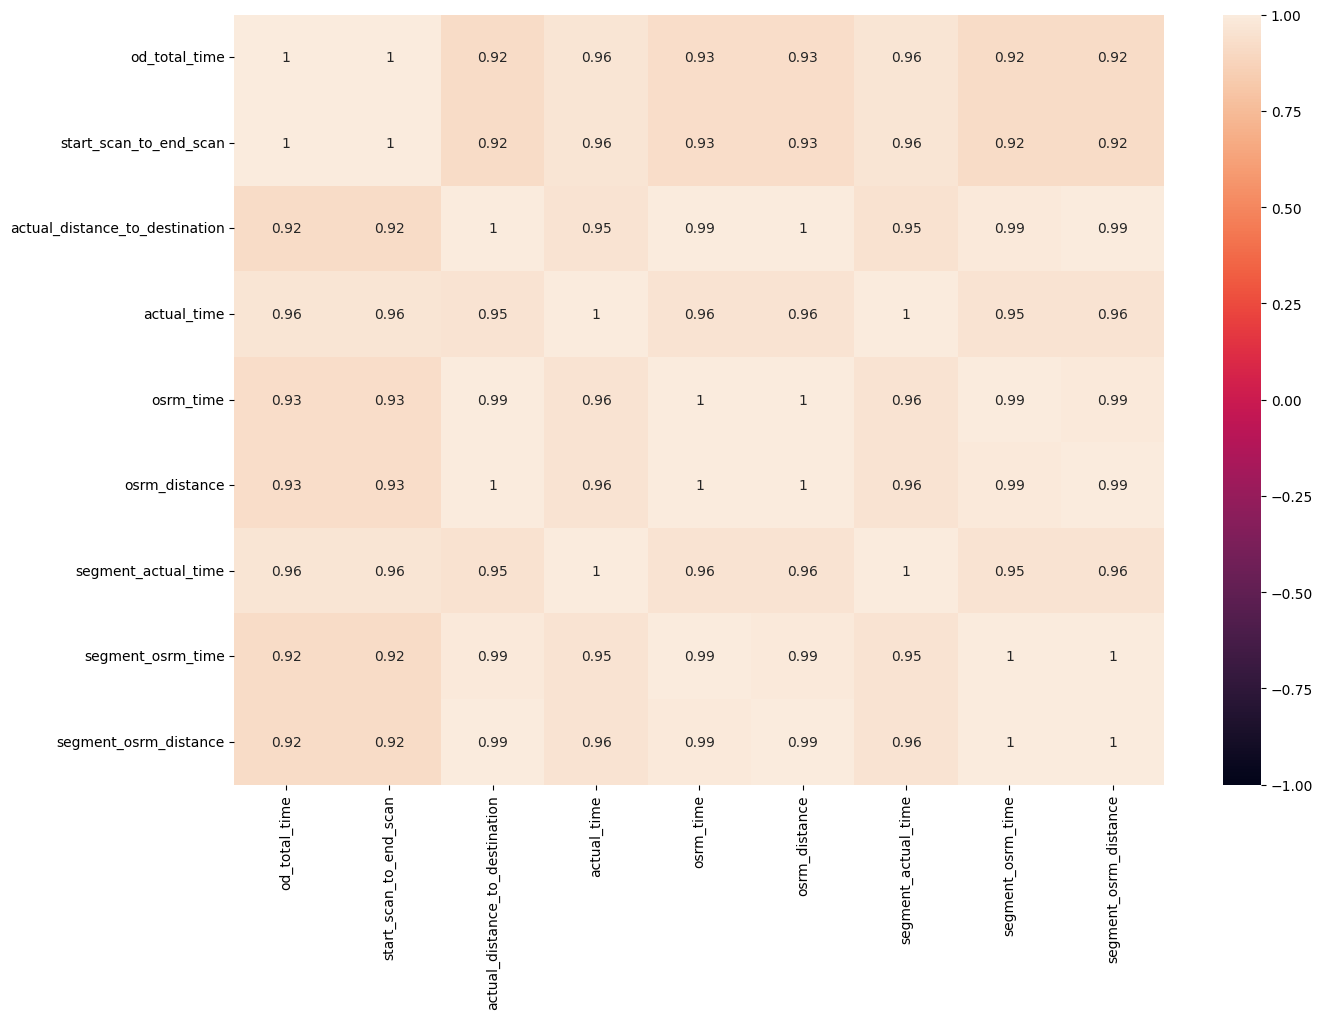

In [ ]:
#heatmap showing correlation between numerical columns:
df_corr = agg2[numerical_columns].corr()
plt.figure(figsize = (15, 10))
sns.heatmap(data = df_corr, vmin = -1, vmax = 1, annot = True)
plt.plot()

In [ ]:
#Very High Correlation (> 0.9) exists between columns all the numerical columns specified above

In [ ]:
#outlier treatments:
numeric_cols = agg2.select_dtypes(include=['number']).columns
for col in numeric_cols:
    q1 = agg2[col].quantile(0.25)
    q3 = agg2[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    agg2[col] = np.clip(agg2[col], lower, upper)
# Step 3: Recalculate IQRs for cleaned data
Q1 = agg2[numeric_cols].quantile(0.25)
Q3 = agg2[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

# Step 4: Check if any outliers still remain
outliers_remaining = agg2[
    ((agg2[numeric_cols] < (Q1 - 1.5 * IQR)) |
     (agg2[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

print("Remaining outliers:", len(outliers_remaining))
print("Final dataset size after outlier treatment:", len(agg2))


Remaining outliers: 0
Final dataset size after outlier treatment: 14787


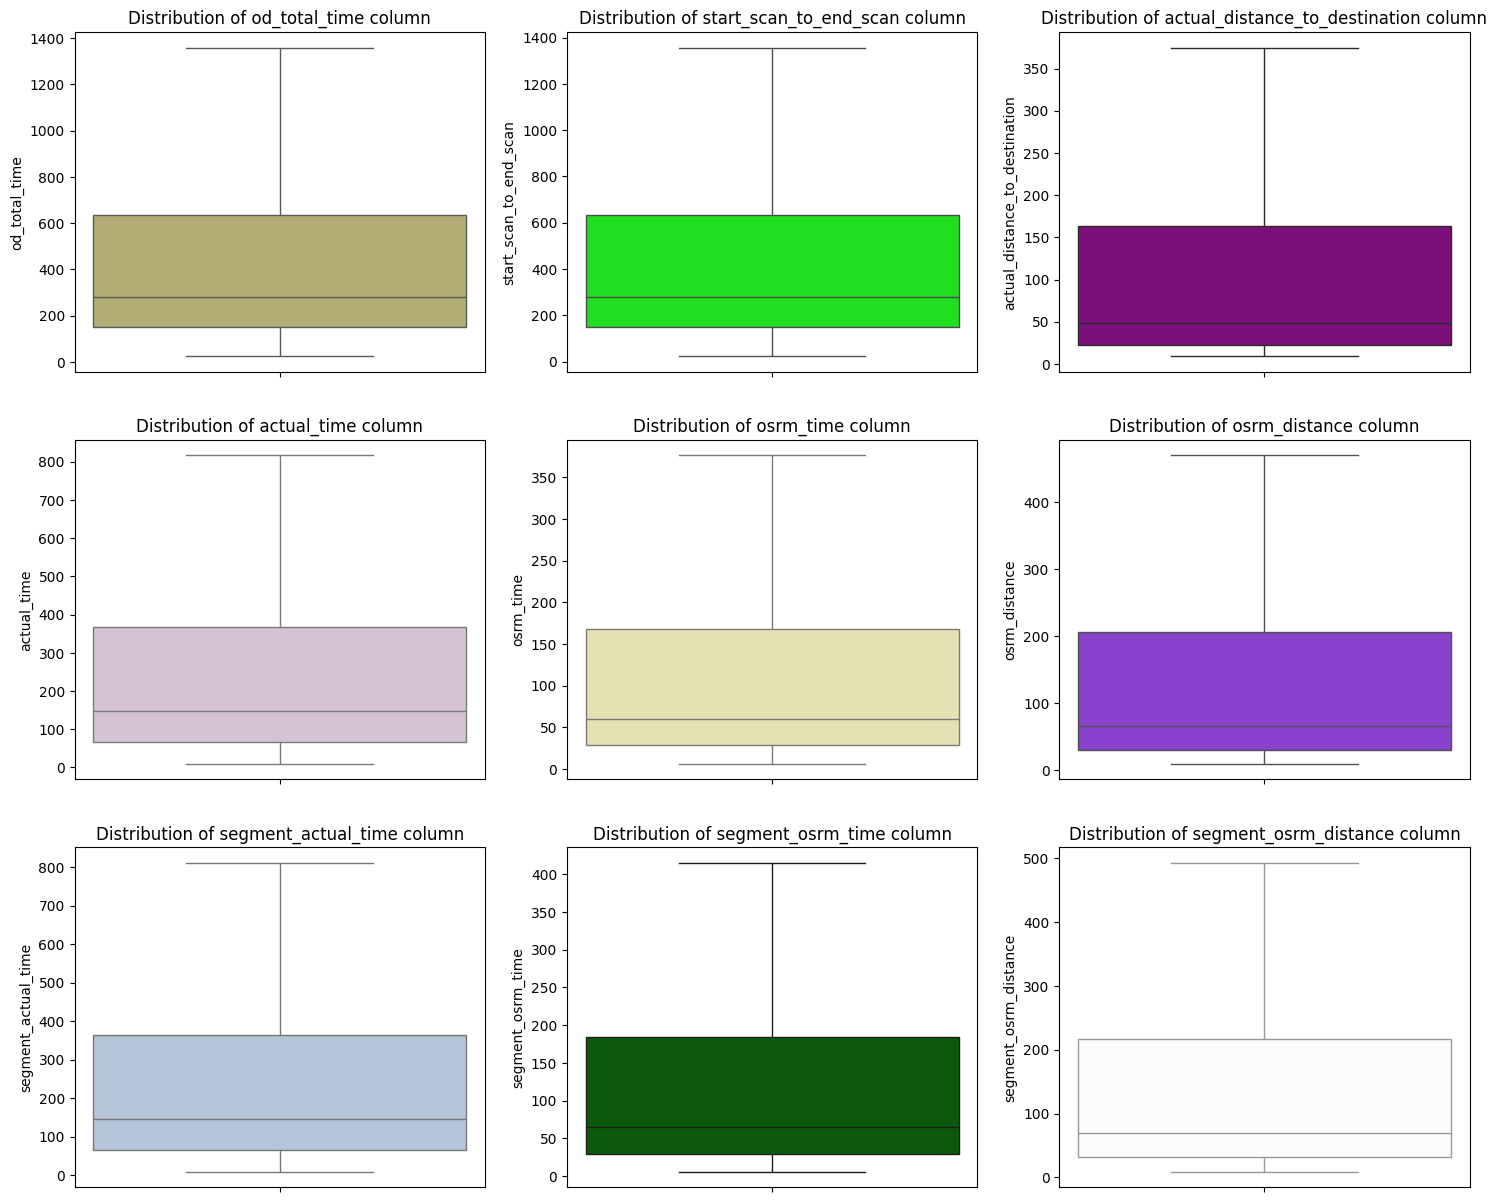

In [ ]:
#post outlier treatment:
plt.figure(figsize = (18, 15))
for i in range(len(numerical_columns)):
 plt.subplot(3, 3, i + 1)
 clr = np.random.choice(list(mpl.colors.cnames))
 sns.boxplot(agg2[numerical_columns[i]], color = clr)
 plt.title(f"Distribution of {numerical_columns[i]} column")
 plt.plot()

In [ ]:
#checking for outliers example:

q1 = agg2['od_total_time'].quantile(0.25)
q3 = agg2['od_total_time'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

# Check if any remaining values are outside
outliers_remaining = agg2[(agg2['od_total_time'] < lower) |
                          (agg2['od_total_time'] > upper)]
print(len(outliers_remaining))

0


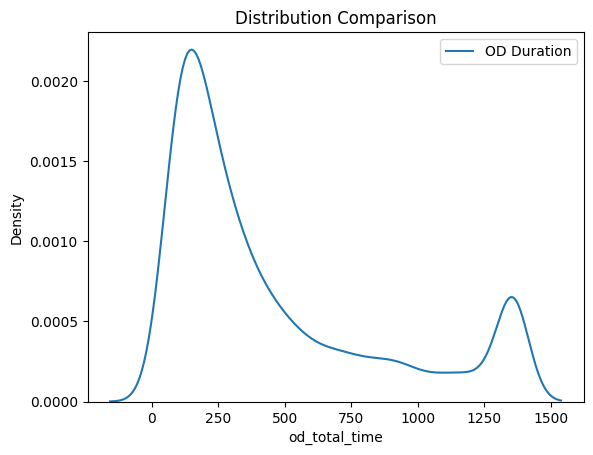

In [ ]:
sns.kdeplot(agg2['od_total_time'], label='OD Duration')

plt.legend()
plt.title("Distribution Comparison")
plt.show()

<Axes: xlabel='start_scan_to_end_scan', ylabel='Density'>

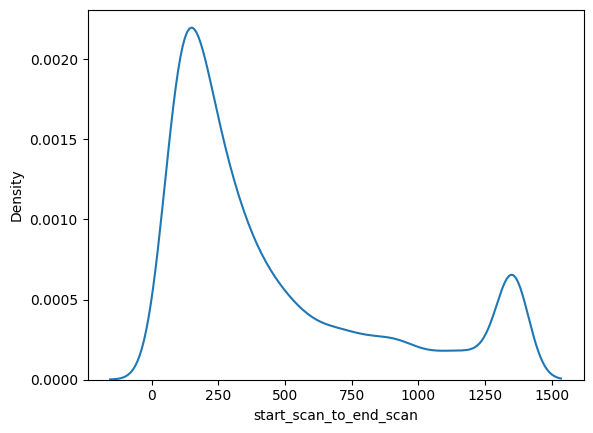

In [ ]:
sns.kdeplot(agg2['start_scan_to_end_scan'], label='Scan Duration')

In [ ]:
agg2['duration_diff'] = agg2['od_total_time']-agg2['start_scan_to_end_scan']

Text(0.5, 1.0, 'Difference Between OD and Scan Duration')

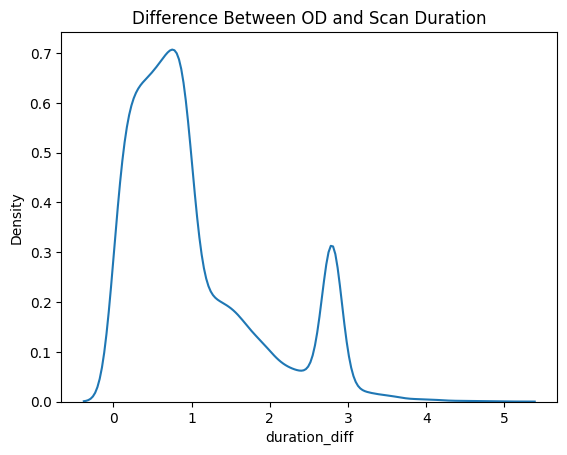

In [ ]:
sns.kdeplot(agg2['duration_diff'])
plt.title("Difference Between OD and Scan Duration")

In [ ]:
#from scipy.stats import boxcox
#agg2['start_scan_to_end_scan_log_n'], _ = boxcox(agg2['start_scan_to_end_scan'])
#sns.kdeplot(agg2['start_scan_to_end_scan_log_n'], label='Scan Duration')

# In-depth analysis and feature engineering:



In [ ]:
#test for normality:
# H0: Data is Gaussian
# Ha: Data is not Gaussian
np.random.sample(42)
subset=agg2['duration_diff'].sample(1000)
test_stat, p_value = shapiro(subset)
print(p_value)
if p_value < 0.05:
  print("Reject H0")
  print("Data is not Gaussian")
else:
  print("Fail to reject H0")
  print("Data is Gaussian")

7.641714285850123e-29
Reject H0
Data is not Gaussian


[]

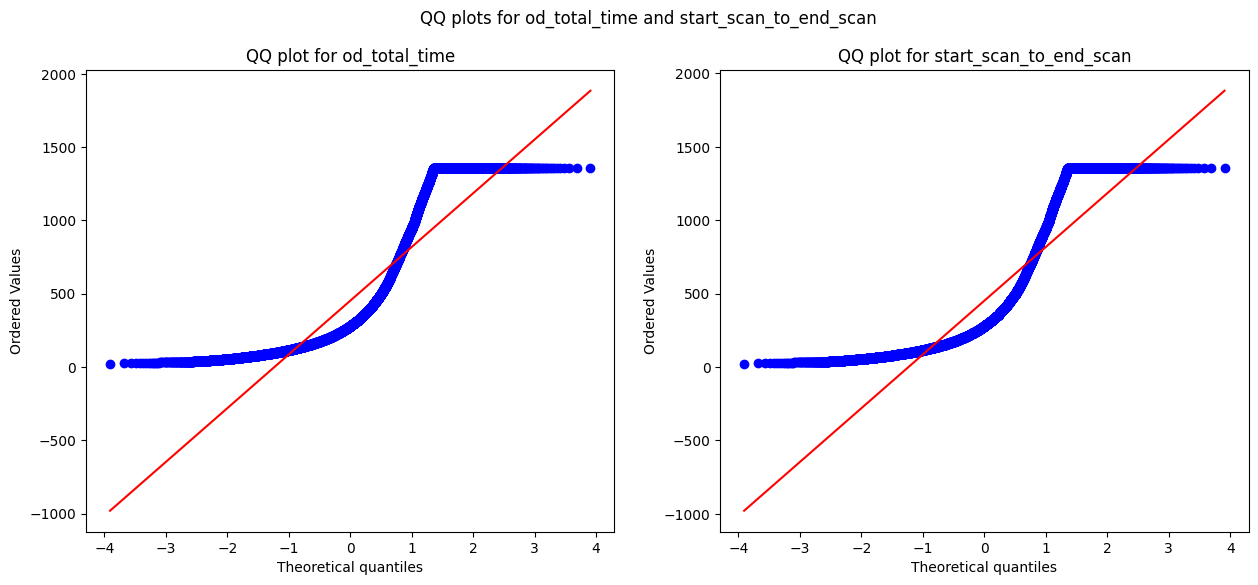

In [ ]:
plt.figure(figsize = (15, 6))
plt.subplot(1, 2, 1)
plt.suptitle('QQ plots for od_total_time and start_scan_to_end_scan')
spy.probplot(agg2['od_total_time'], plot = plt, dist = 'norm')
plt.title('QQ plot for od_total_time')
plt.subplot(1, 2, 2)
spy.probplot(agg2['start_scan_to_end_scan'], plot = plt, dist = 'norm')
plt.title('QQ plot for start_scan_to_end_scan')
plt.plot()

In [ ]:
#test for normality:
# H0: Data is Gaussian
# Ha: Data is not Gaussian
np.random.sample(42)
subset=agg2['duration_diff'].sample(1000)
test_stat, p_value = shapiro(subset)
print(p_value)
if p_value < 0.05:
  print("Reject H0")
  print("Data is not Gaussian")
else:
  print("Fail to reject H0")
  print("Data is Gaussian")

1.4145298993104191e-28
Reject H0
Data is not Gaussian


In [ ]:
# Null Hypothesis(H0) - Homogenous Variance
# Alternate Hypothesis(HA) - Non Homogenous Variance
test_stat, p_value = spy.levene(agg2['od_total_time'], agg2['start_scan_to_end_scan'])
print('p-value', p_value)
if p_value < 0.05:
 print('The samples do not have Homogenous Variance')
else:
 print('The samples have Homogenous Variance')

p-value 0.9088042067058311
The samples have Homogenous Variance


In [ ]:
from scipy.stats import wilcoxon

#hypothesis test 1 :
#h0: no significant difference between od_total_time  and start_scan_to_end_scan.
#h1: there is a significant difference between them.
stat, p_value = wilcoxon(agg2['od_total_time'], agg2['start_scan_to_end_scan'])
print("Wilcoxon statistic:", stat)
print("P-value:", p_value)
if p_value < 0.05:
  print("Reject H0")
else:
  print("Fail to reject H0")
# Statistically significant difference between od_total_time and start_scan_to_end_scan, even though the absolute difference is small.

Wilcoxon statistic: 0.0
P-value: 0.0
Reject H0


In [ ]:
agg2[['od_total_time','start_scan_to_end_scan','duration_diff']].describe()
#shows the absolute difference is small, but there is a difference.

,od_total_time,start_scan_to_end_scan,duration_diff
count,14787.000000,14787.000000,14787.000000
mean,452.242358,451.207344,1.035014
std,407.792084,407.201397,0.857518
min,23.460000,23.000000,0.000000
25%,149.695000,149.000000,0.410000
50%,279.710000,279.000000,0.780000
75%,633.535000,632.000000,1.400000
max,1359.295000,1356.500000,5.010000


[]

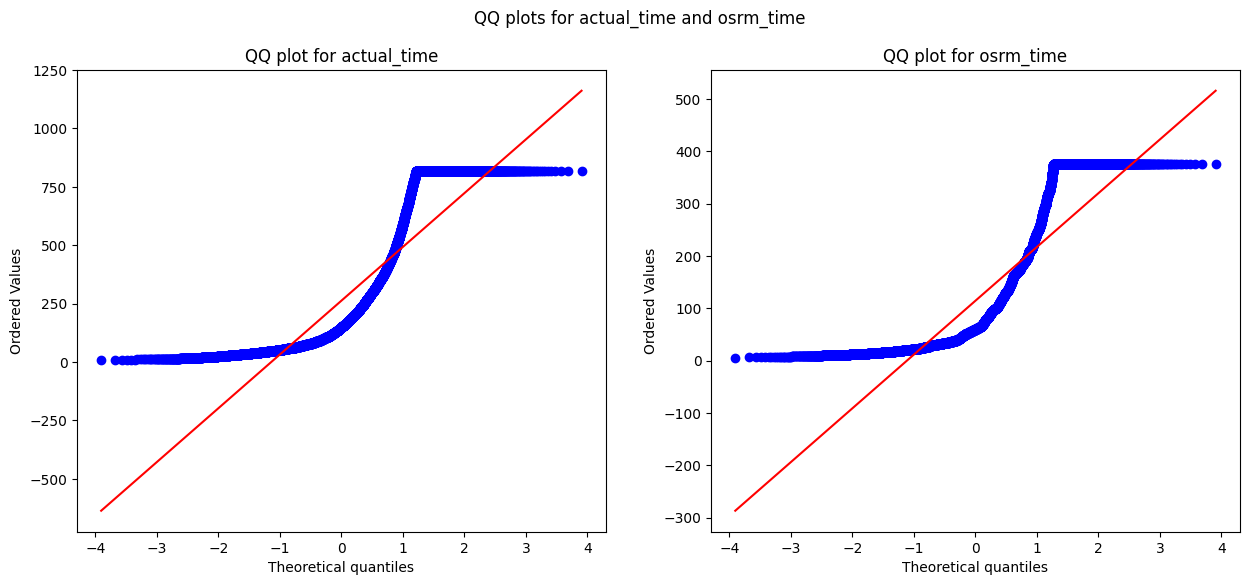

In [ ]:
#actual_time vs osrm_time:

plt.figure(figsize = (15, 6))
plt.subplot(1, 2, 1)
plt.suptitle('QQ plots for actual_time and osrm_time')
spy.probplot(agg2['actual_time'], plot = plt, dist = 'norm')
plt.title('QQ plot for actual_time')
plt.subplot(1, 2, 2)
spy.probplot(agg2['osrm_time'], plot = plt, dist = 'norm')
plt.title('QQ plot for osrm_time')
plt.plot()

In [ ]:
#shapiro-wilk test:

from scipy.stats import shapiro
stat, p_value = shapiro(agg2['actual_time'])
print(p_value)
if p_value < 0.05:
  print("Reject H0")
  print("Data is not Gaussian")
else:
  print("Fail to reject H0")
  print("Data is Gaussian")

7.156152453374487e-87
Reject H0
Data is not Gaussian


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 14787.
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
#shapiro-wilk test:
stat, p_value = shapiro(agg2['osrm_time'])
print(p_value)
if p_value < 0.05:
  print("Reject H0")
  print("Data is not Gaussian")
else:
  print("Fail to reject H0")
  print("Data is Gaussian")

1.1371379380591452e-87
Reject H0
Data is not Gaussian


In [ ]:
#levene test:

# Null Hypothesis(H0) - Homogenous Variance
# Alternate Hypothesis(HA) - Non Homogenous Variance
test_stat, p_value = spy.levene(agg2['actual_time'], agg2['osrm_time'])
print('p-value', p_value)
if p_value < 0.05:
 print('The samples do not have Homogenous Variance')
else:
 print('The samples have Homogenous Variance ')

p-value 0.0
The samples do not have Homogenous Variance


In [ ]:
#hypothesis test 2 :
#h0: no significant difference between actual_time  and OSRM time.
#h1: there is a significant difference between them.
stat, p_value = wilcoxon(agg2['actual_time'], agg2['osrm_time'])
print("Wilcoxon statistic:", stat)
print("P-value:", p_value)

if p_value < 0.05:
  print("Reject H0")
else:
  print("Fail to reject H0")

#statistically significant difference between actual delivery time and OSRM-predicted time.
#sample clearly shows actual_time is almost always greater than osrm_time

Wilcoxon statistic: 95688.5
P-value: 0.0
Reject H0


In [ ]:
agg2[['actual_time','osrm_time']].describe()

,actual_time,osrm_time
count,14787.000000,14787.000000
mean,262.292892,114.495638
std,259.049182,116.158042
min,9.000000,6.000000
25%,67.000000,29.000000
50%,148.000000,60.000000
75%,367.000000,168.000000
max,817.000000,376.500000


In [ ]:
agg2[['actual_time','osrm_time']].median()
#sample clearly shows actual_time is almost always greater than osrm_time

,0
actual_time,148.0
osrm_time,60.0


[]

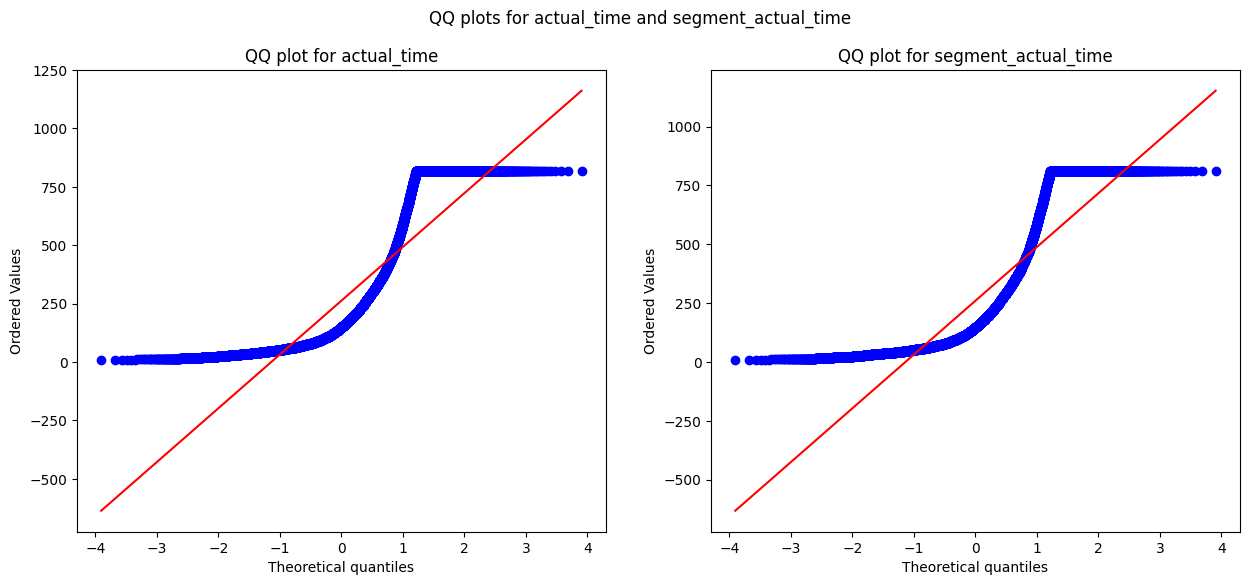

In [ ]:
#actual_time vs segment_actual_time:
plt.figure(figsize = (15, 6))
plt.subplot(1, 2, 1)
plt.suptitle('QQ plots for actual_time and segment_actual_time')
spy.probplot(agg2['actual_time'], plot = plt, dist = 'norm')
plt.title('QQ plot for actual_time')
plt.subplot(1, 2, 2)
spy.probplot(agg2['segment_actual_time'], plot = plt, dist = 'norm')
plt.title('QQ plot for segment_actual_time')
plt.plot()


In [ ]:
#shapiro wilk:
test_stat, p_value = spy.shapiro(agg2['actual_time'].sample(1000))
print('p-value', p_value)
if p_value < 0.05:
  print("Data is not Gaussian")
else:
  print("Data is Gaussian")

p-value 3.7198167576553576e-34
Data is not Gaussian


In [ ]:
#shapiro wilk:
test_stat, p_value = spy.shapiro(agg2['segment_actual_time'].sample(1000))
print('p-value', p_value)
if p_value < 0.05:
  print("Data is not Gaussian")
else:
  print("Data is Gaussian")

p-value 1.498593005454351e-33
Data is not Gaussian


In [ ]:
#levene test:
# Null Hypothesis(H0) - Homogenous Variance
# Alternate Hypothesis(HA) - Non Homogenous Variance
test_stat, p_value = spy.levene(agg2['actual_time'], agg2['segment_actual_time'])
print('p-value', p_value)
if p_value < 0.05:
 print('The samples do not have Homogenous Variance')
else:
 print('The samples have Homogenous Variance ')

p-value 0.5627578554257575
The samples have Homogenous Variance 


In [ ]:
##hypothesis test 3 :
#h0: no significant difference between actual_time  and segment_actual_time.
#h1: there is a significant difference between them.
stat, p_value = wilcoxon(agg2['actual_time'], agg2['segment_actual_time'])
print("Wilcoxon statistic:", stat)
print("P-value:", p_value)

if p_value < 0.05:
  print("Reject H0")
else:
  print("Fail to reject H0")

#While the Wilcoxon test reveals a statistically significant difference.
#actual_time and segment_actual_time, the median difference is only 1 minute, suggesting it may not be practically significant.

Wilcoxon statistic: 0.0
P-value: 0.0
Reject H0


In [ ]:
agg2[['actual_time','segment_actual_time']].describe()

,actual_time,segment_actual_time
count,14787.000000,14787.000000
mean,262.292892,260.021235
std,259.049182,257.238614
min,9.000000,9.000000
25%,67.000000,66.000000
50%,148.000000,147.000000
75%,367.000000,364.000000
max,817.000000,811.000000


[]

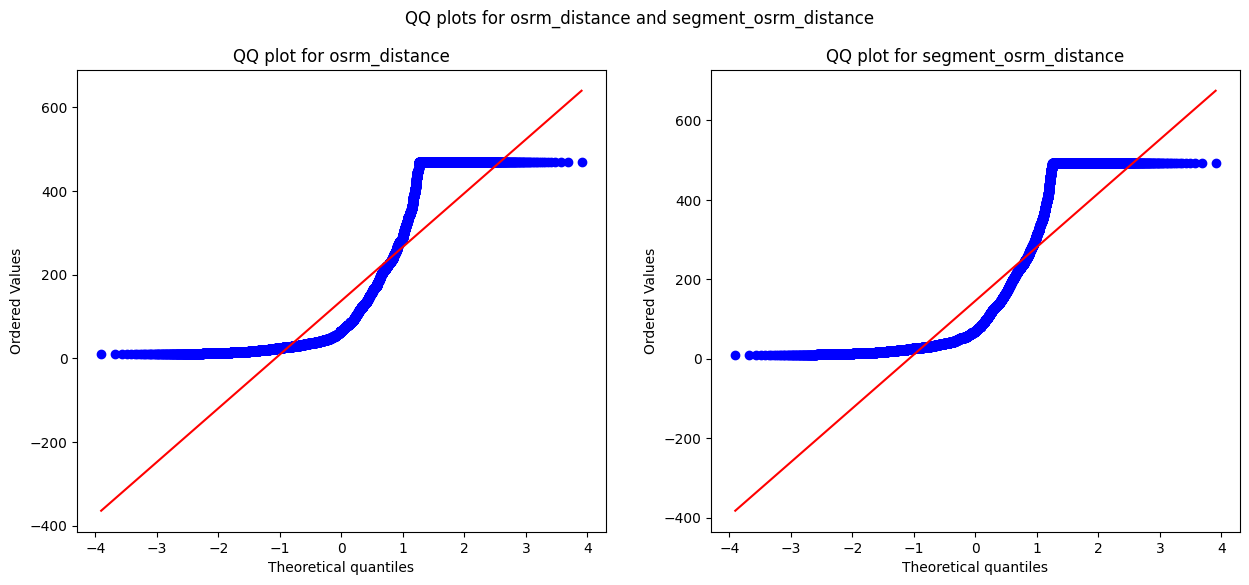

In [ ]:
#osrm_distance vs segment_osrm_distance:
plt.figure(figsize = (15, 6))
plt.subplot(1, 2, 1)
plt.suptitle('QQ plots for osrm_distance and segment_osrm_distance')
spy.probplot(agg2['osrm_distance'], plot = plt, dist = 'norm')
plt.title('QQ plot for osrm_distance')
plt.subplot(1, 2, 2)
spy.probplot(agg2['segment_osrm_distance'], plot = plt, dist = 'norm')
plt.title('QQ plot for segment_osrm_distance')
plt.plot()

In [ ]:
#shapiro wilk:
test_stat, p_value = spy.shapiro(agg2['osrm_distance'].sample(1000))
print('p-value', p_value)
if p_value < 0.05:
  print("Data is not Gaussian")
else:
  print("Data is Gaussian")

p-value 2.291577483112571e-35
Data is not Gaussian


In [ ]:
#shapiro wilk:
test_stat, p_value = spy.shapiro(agg2['segment_osrm_distance'].sample(1000))
print('p-value', p_value)
if p_value < 0.05:
  print("Data is not Gaussian")
else:
  print("Data is Gaussian")

p-value 7.93804546580812e-35
Data is not Gaussian


In [ ]:
#levene test:
# Null Hypothesis(H0) - Homogenous Variance
# Alternate Hypothesis(HA) - Non Homogenous Variance
test_stat, p_value = spy.levene(agg2['osrm_distance'], agg2['segment_osrm_distance'])
print('p-value', p_value)
if p_value < 0.05:
 print('The samples do not have Homogenous Variance')
else:
 print('The samples have Homogenous Variance ')

p-value 0.00010200956072621835
The samples do not have Homogenous Variance


In [ ]:
##hypothesis test 4 :
#h0: no significant difference between osrm_distance  and segment_osrm_distance.
#h1: there is a significant difference between them.
stat, p_value = wilcoxon(agg2['osrm_distance'], agg2['segment_osrm_distance'])
print("Wilcoxon statistic:", stat)
print("P-value:", p_value)

if p_value < 0.05:
  print("Reject H0")
else:
  print("Fail to reject H0")
#While the Wilcoxon test reveals a statistically significant difference.
#osrm_distance and segment_osrm_distance, the median difference is minute, suggesting it may not be practically significant.

Wilcoxon statistic: 10922304.5
P-value: 0.0
Reject H0


In [ ]:
agg2[['osrm_distance','segment_osrm_distance']].describe()

,osrm_distance,segment_osrm_distance
count,14787.000000,14787.000000
mean,137.616390,145.887640
std,146.531653,153.745550
min,9.072900,9.072900
25%,30.756900,32.578850
50%,65.302800,69.784200
75%,206.644200,216.560600
max,470.475150,492.533225


[]

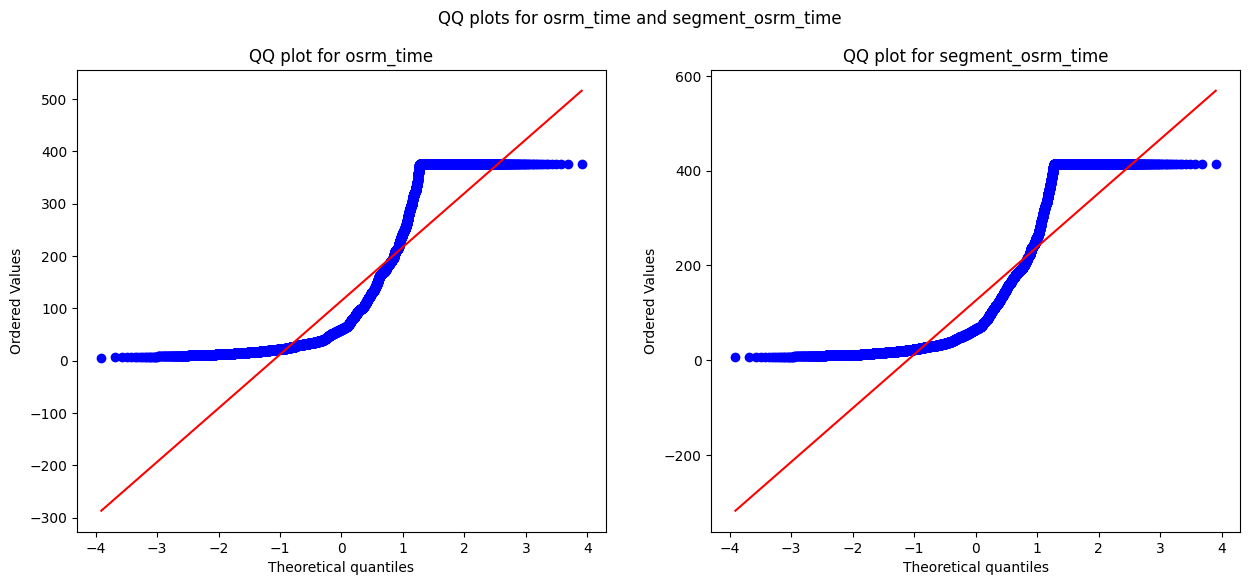

In [ ]:
#osrm time vs segment osrm time:
plt.figure(figsize = (15, 6))
plt.subplot(1, 2, 1)
plt.suptitle('QQ plots for osrm_time and segment_osrm_time')
spy.probplot(agg2['osrm_time'], plot = plt, dist = 'norm')
plt.title('QQ plot for osrm_time')
plt.subplot(1, 2, 2)
spy.probplot(agg2['segment_osrm_time'], plot = plt, dist = 'norm')
plt.title('QQ plot for segment_osrm_time')
plt.plot()

In [ ]:
#shapiro wilk:
test_stat, p_value = spy.shapiro(agg2['osrm_time'].sample(1000))
print('p-value', p_value)
if p_value < 0.05:
  print("Data is not Gaussian")
else:
  print("Data is Gaussian")

p-value 1.490947604853758e-34
Data is not Gaussian


In [ ]:
#shapiro wilk:
test_stat, p_value = spy.shapiro(agg2['segment_osrm_time'].sample(1000))
print('p-value', p_value)
if p_value < 0.05:
  print("Data is not Gaussian")
else:
  print("Data is Gaussian")

p-value 2.567532257973055e-34
Data is not Gaussian


In [ ]:
#levene test:
# Null Hypothesis(H0) - Homogenous Variance
# Alternate Hypothesis(HA) - Non Homogenous Variance
test_stat, p_value = spy.levene(agg2['osrm_time'], agg2['segment_osrm_time'])
print('p-value', p_value)
if p_value < 0.05:
 print('The samples do not have Homogenous Variance')
else:
 print('The samples have Homogenous Variance ')

p-value 3.4829573626719775e-14
The samples do not have Homogenous Variance


In [ ]:
##hypothesis test 5 :
#h0: no significant difference between osrm time  and segment osrm time.
#h1: there is a significant difference between them.
stat, p_value = wilcoxon(agg2['osrm_time'], agg2['segment_osrm_time'])
print("Wilcoxon statistic:", stat)
print("P-value:", p_value)

if p_value < 0.05:
  print("Reject H0")
else:
  print("Fail to reject H0")

#While the Wilcoxon test reveals a statistically significant difference.
#osrm and segment osrm time, the median difference is minute, suggesting it may not be practically significant.

Wilcoxon statistic: 12919394.0
P-value: 0.0
Reject H0


In [ ]:
agg2[['osrm_time','segment_osrm_time']].describe()

,osrm_time,segment_osrm_time
count,14787.000000,14787.000000
mean,114.495638,125.597620
std,116.158042,128.074017
min,6.000000,6.000000
25%,29.000000,30.000000
50%,60.000000,65.000000
75%,168.000000,184.000000
max,376.500000,415.000000


#One hot coding:

In [ ]:
agg2['route_type'].value_counts()

,count
route_type,
Carting,8906
FTL,5881


In [ ]:
#Perform one-hot encoding on categorical column route type
label=LabelEncoder()
agg2['route_type']=label.fit_transform(agg2['route_type'])


In [ ]:
agg2['route_type'].value_counts()

,count
route_type,
0,8906
1,5881


In [ ]:
agg2['data'].value_counts()

,count
data,
training,10645
test,4142


In [ ]:
#Perform one-hot encoding on categorical column data
label=LabelEncoder()
agg2['data']=label.fit_transform(agg2['data'])

In [ ]:
agg2['data'].value_counts()

,count
data,
1,10645
0,4142


#Normalize/ Standardize the numerical features using MinMaxScaler or StandardScaler

In [ ]:
#since the data is not gaussian, using minmax would be the best as StandardScaler is used on Gaussian data.

In [ ]:
num_cols = agg2.select_dtypes(include=['number']).columns
scaler = MinMaxScaler()
agg2[num_cols] = scaler.fit_transform(agg2[num_cols])
agg2[num_cols]

,data,route_type,month,year,days,hour,od_total_time,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,duration_diff
0,1.0,1.0,0.0,0.0,0.379310,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.557884
1,1.0,0.0,0.0,0.0,0.379310,0.0,0.118390,0.117735,0.175458,0.165842,0.167341,0.164798,0.164589,0.144254,0.155373,0.321357
2,1.0,1.0,0.0,0.0,0.379310,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.557884
3,1.0,0.0,0.0,0.0,0.379310,0.0,0.057664,0.057743,0.022342,0.061881,0.024291,0.022989,0.062344,0.024450,0.022347,0.097804
4,1.0,1.0,0.0,0.0,0.379310,0.0,0.520184,0.520435,0.323791,0.410891,0.299595,0.298479,0.412718,0.266504,0.284861,0.267465
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14782,0.0,0.0,0.0,0.0,0.068966,1.0,0.175598,0.175478,0.133293,0.091584,0.151147,0.139553,0.091022,0.136919,0.115381,0.205589
14783,0.0,0.0,0.0,0.0,0.068966,1.0,0.027795,0.027747,0.017800,0.014851,0.016194,0.015204,0.014963,0.012225,0.014511,0.117764
14784,0.0,0.0,0.0,0.0,0.068966,1.0,0.298435,0.298463,0.081142,0.337871,0.113360,0.107999,0.339152,0.200489,0.198183,0.223553
14785,0.0,0.0,0.0,0.0,0.068966,1.0,0.243338,0.242970,0.343679,0.315594,0.466937,0.351185,0.310474,0.525672,0.443593,0.303393


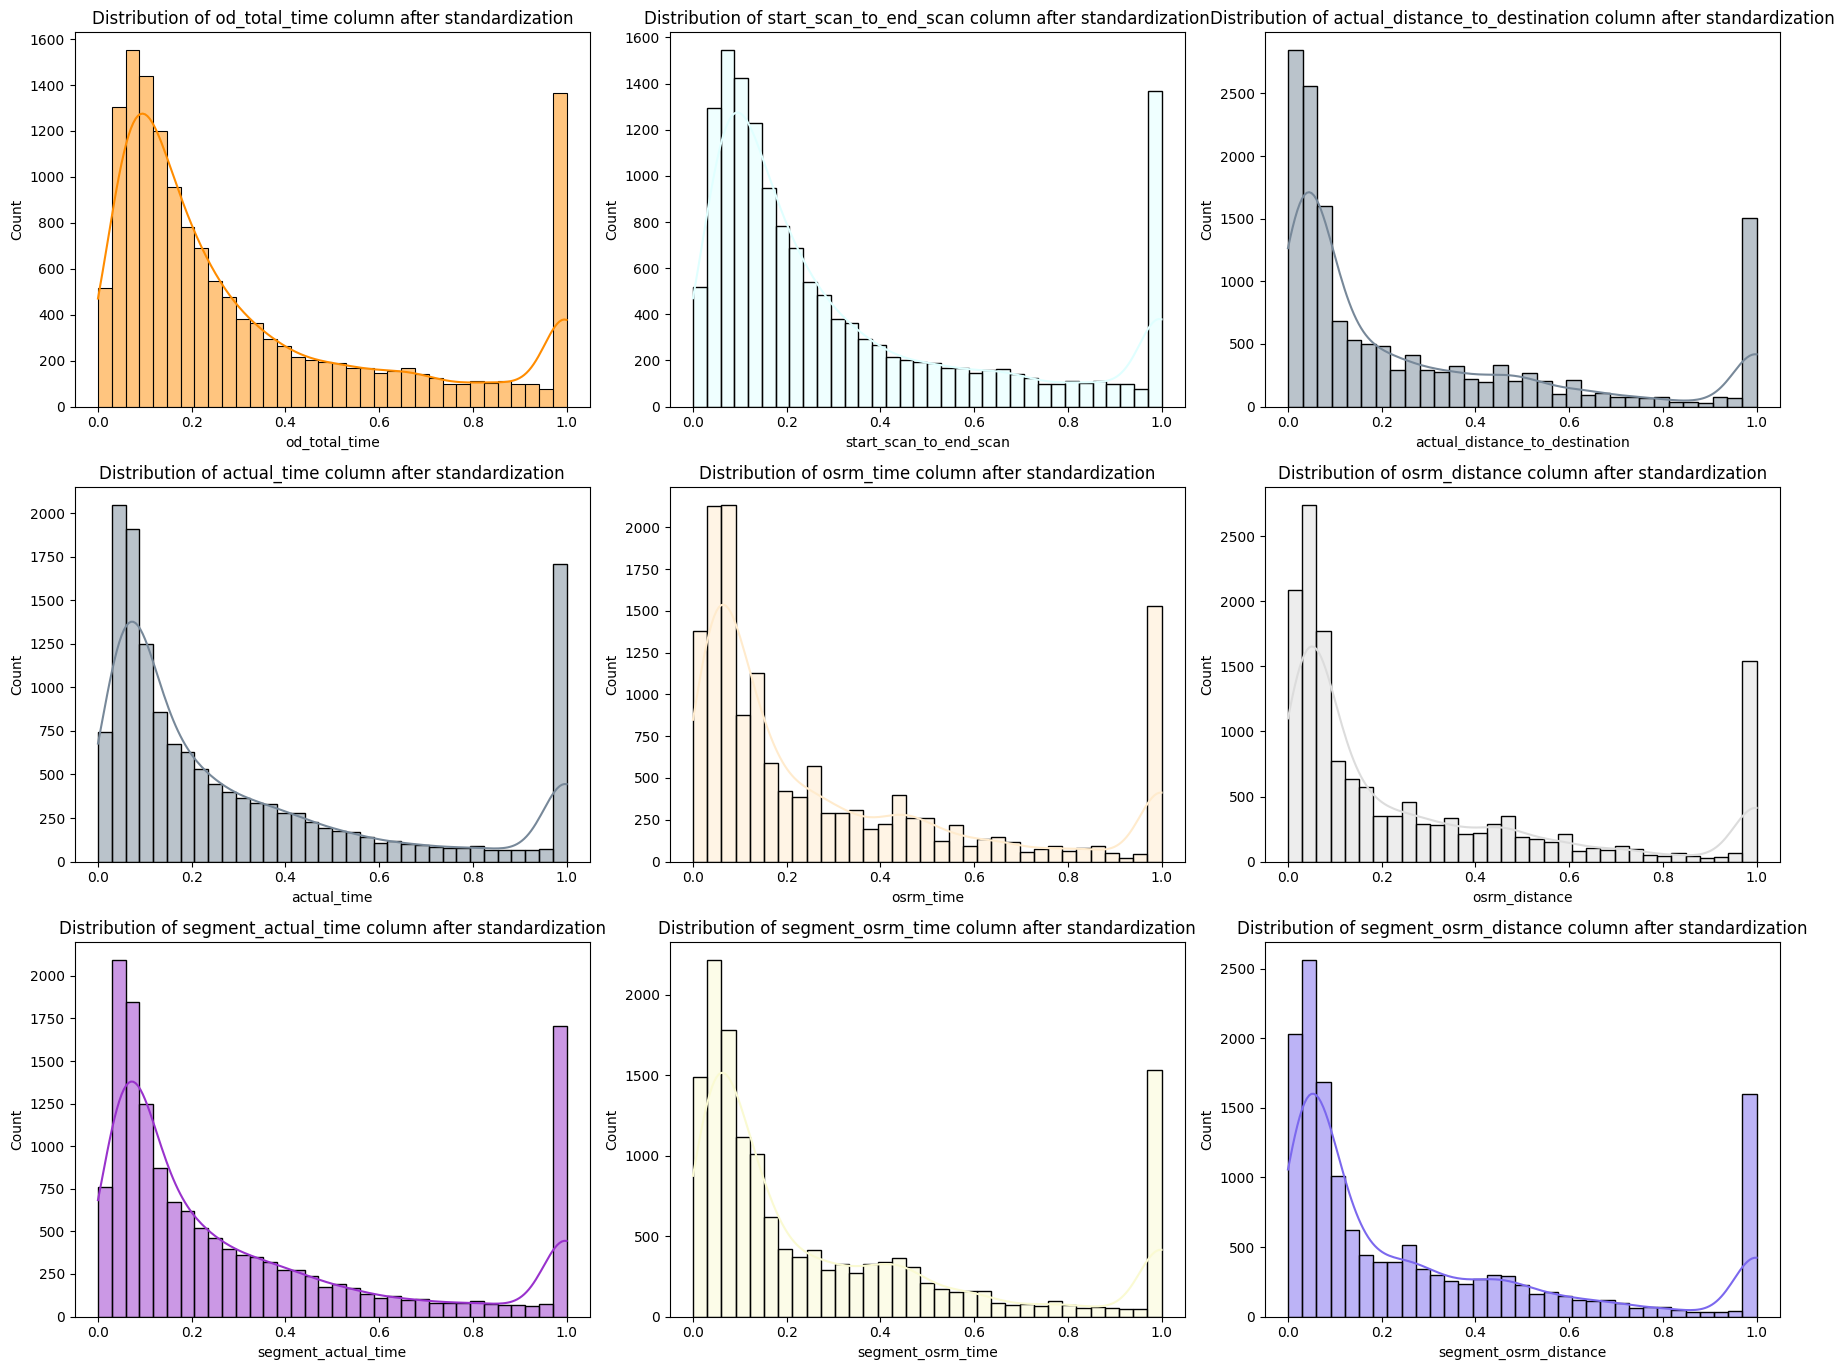

In [ ]:
#plots after normalization:


plt.figure(figsize = (18, 15))
for i in range(len(numerical_columns)):
 plt.subplot(3, 3, i + 1)
 clr = np.random.choice(list(mpl.colors.cnames))
 sns.histplot(agg2[numerical_columns[i]], kde = True, color = clr)
 plt.title(f"Distribution of {numerical_columns[i]} column after standardization")
 plt.tight_layout(rect=[0, 0.03, 1, 0.95])
 plt.plot()



#Business Insights:


*   There are about 14817 unique trip IDs, 1508 unique source centers, 1481 unique destination_centers, 690 unique source cities, 806
unique destination cities.

*   Most of the data is for training than for testing.


*   Most common route type is Carting

*   The number of trips start increasing after the noon, becomes maximum at 10 P.M and then start decreasing

*   Most orders come mid-month. That means customers usually make more orders in the mid of the month



*   Most orders are sourced from the states like Maharashtra, Karnataka, Haryana, Tamil Nadu, Telangana.

*   Maximum number of trips originated from Gurgaon city followed by  Bengaluru, Mumbai and Bhiwandi. That means that the seller
base is strong in these cities.


*   Maximum number of trips ended in Maharashtra state followed by Karnataka, Haryana, Tamil Nadu and Telanagna. That means that
the number of orders placed in these states is significantly high.

*   Maximum number of trips ended in Mumbai city followed by Bengaluru, Gurgaon, Delhi. That means that the number of
orders placed in these cities is significantly high.

*   We used wilcoxon test as it is non parametric and data is not Gaussian.


*   Features start_scan_to_end_scan and od_total_time(created feature) are not statistically similar.


*   Features start_scan_to_end_scan and od_total_time are not statistically similar.


*   Features actual_time & osrm_time a are not statistically similar.


*   Features  start_scan_to_end_scan and segment_actual_time are notstatistically similar.


*   Features osrm_distance and segment_osrm_distance are not statistically similar.


*   Features  osrm_time & segment_osrm_time are not statistically similar.



*   Also Data is not normal.
*   Outliers are heavy and data is right skewed. The outliers might be true otuliers and removal of them can affect analaysis. But for modelling purposes they have been clipped.





#Recommendations:


* The OSRM trip planning system needs to be improved. Discrepancies need to be catered to for transporters, if the routing engine is
configured for optimum results

* osrm_time and actual_time are different. Team needs to make sure this difference is reduced, so that better delivery time prediction can
be made and it becomes convenient for the customer to expect an accurate delivery time

*   Most of the orders are coming from/reaching to states like Maharashtra, Karnataka, Haryana and Tamil Nadu. The existing corridors can
be further enhanced to improve the penetration in these areas.


*   Customer profiling of the customers belonging to the above states  has to be
done to get to know why major orders are coming from these states and to improve customers' buying and delivery experience.

*   Understand why the low profile states have less orders.


*   Understand the Terrains for the states with less orders. To understand the mode of shipping.


*   The osrm distance and actual distance covered are also not same i.e. maybe the delivery person is not following the predefined route
which may lead to late deliveries or the osrm devices is not properly predicting the route based on distance, traffic and other factors.
Team needs to look into it.




